# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis
import fm.scaling_utils as scalingUtils

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


# Utils

In [4]:
DATASET_TAG = "unbalanced"   # o balanced
PREPARED_DIR = "../results/prepared_splits"

SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_GLOBAL__Y_LOCAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

CLASS_COL = "class"

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt",
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# Loading & Preparing the DataFrames

In [6]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

In [7]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=0)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [8]:
# -----------------------
# Split raw data
# -----------------------

df_all_train, df_all_val, df_all_test = data.split_df_once(df_all)
df_bal_train, df_bal_val, df_bal_test = data.split_df_once(df_bal)

print("ALL splits")
print("train:", df_all_train.shape)
print("val  :", df_all_val.shape)
print("test :", df_all_test.shape)

print()

print("BALANCED splits")
print("train:", df_bal_train.shape)
print("val  :", df_bal_val.shape)
print("test :", df_bal_test.shape)

ALL splits
train: (269880, 76)
val  : (33735, 76)
test : (33736, 76)

BALANCED splits
train: (131115, 76)
val  : (16389, 76)
test : (16390, 76)


# Standard Scaling on X Variables

In [11]:
# -----------------------
# Fit X scalers on TRAIN only
# -----------------------

CLASS_COL = "class"

# ---------- ALL ----------
# scaler globale:
x_scaler_all_global = StandardScaler().fit(
    df_all_train[train_cols].to_numpy()
)

# scaler locale:
df_all_train_dy = df_all_train[df_all_train[CLASS_COL] == 0]
df_all_train_h  = df_all_train[df_all_train[CLASS_COL] == 1]

x_scaler_all_local = {
    0: StandardScaler().fit(df_all_train_dy[train_cols].to_numpy()),
    1: StandardScaler().fit(df_all_train_h[train_cols].to_numpy()),
}

# ---------- BALANCED ----------
x_scaler_bal_global = StandardScaler().fit(
    df_bal_train[train_cols].to_numpy()
)

df_bal_train_dy = df_bal_train[df_bal_train[CLASS_COL] == 0]
df_bal_train_h  = df_bal_train[df_bal_train[CLASS_COL] == 1]

x_scaler_bal_local = {
    0: StandardScaler().fit(df_bal_train_dy[train_cols].to_numpy()),
    1: StandardScaler().fit(df_bal_train_h[train_cols].to_numpy()),
}

print("X scalers fitted for ALL and BALANCED.")

X scalers fitted for ALL and BALANCED.


In [12]:
# -----------------------
# Applico gli scaling di X sui TEST dfs
# -----------------------

df_all_test_raw = df_all_test.copy()

df_all_test_global = scalingUtils.transform_X_global(
    df_in=df_all_test,
    train_cols=train_cols,
    scaler=x_scaler_all_global,
)

df_all_test_local = scalingUtils.transform_X_local(
    df_in=df_all_test,
    train_cols=train_cols,
    scaler_dict=x_scaler_all_local,
    class_col=CLASS_COL,
)

df_bal_test_raw = df_bal_test.copy()

df_bal_test_global = scalingUtils.transform_X_global(
    df_in=df_bal_test,
    train_cols=train_cols,
    scaler=x_scaler_bal_global,
)

df_bal_test_local = scalingUtils.transform_X_local(
    df_in=df_bal_test,
    train_cols=train_cols,
    scaler_dict=x_scaler_bal_local,
    class_col=CLASS_COL,
)

In [13]:
# mini check che siano effettivamente diversi:
df_all_test_raw[train_cols].describe().head()

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,MET_logpt,MET_phi,MET_significance,MET_sumEt
count,33736.000000,33736.000000,33736.000000,3.373600e+04,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,...,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000
mean,3.926568,-0.004295,-0.009841,1.528144e+00,-0.004060,0.012948,1.033807,0.948617,0.702690,-0.001067,...,-0.009997,3.835680,1.453754,-0.001857,-0.003491,2.333029,3.330440,0.241385,2.493099,1521.982767
std,0.305118,1.114163,1.812377,2.147790e+00,1.200400,2.769192,0.104150,0.075796,0.674489,1.000014,...,1.497686,3.543547,1.508155,1.932807,1.257558,2.653191,0.720568,1.633460,3.859883,524.738945
min,3.404875,-2.498047,-3.141602,5.015172e-07,-104.375000,-183.914062,0.451416,0.642090,-1.000000,-1.000000,...,-3.141113,0.000000,0.000000,-5.075195,-3.141602,0.000000,-1.640533,-3.141602,0.000088,180.500000
25%,3.714722,-0.830811,-1.570801,5.043945e-01,-0.002054,-0.004122,1.006836,0.934082,0.936035,-1.000000,...,-0.889435,0.000000,0.000000,0.000000,0.000000,0.000000,2.945301,-0.942291,0.606934,1138.000000


In [14]:
df_all_test_global[train_cols].describe().head()

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,MET_logpt,MET_phi,MET_significance,MET_sumEt
count,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,...,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000
mean,0.011144,-0.002914,-0.011252,0.004309,-0.001340,0.004180,-0.004400,0.008106,0.000237,-0.001267,...,0.000373,0.008677,0.008065,-0.007089,-0.000219,0.008569,-0.003724,0.012555,0.002582,0.014595
std,1.010677,0.998398,0.998141,1.013502,1.307140,0.950525,1.004547,0.990590,0.999457,1.000014,...,1.001403,1.019880,1.001828,1.002965,1.003629,1.000315,1.017166,0.992961,0.964820,1.015207
min,-1.716918,-2.237558,-1.736025,-0.716793,-113.652963,-63.128768,-5.621691,-3.997927,-2.522808,-1.000200,...,-2.093195,-1.095283,-0.957625,-2.639727,-2.504675,-0.871038,-7.020838,-2.043924,-0.620573,-2.580758
25%,-0.690577,-0.743553,-0.870929,-0.478779,0.000845,-0.001679,-0.264543,-0.181847,0.346006,-1.000200,...,-0.587648,-1.095283,-0.957625,-0.006125,0.002567,-0.871038,-0.547392,-0.706988,-0.468886,-0.728293


In [15]:
df_all_test_local[train_cols].describe().head()

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,MET_logpt,MET_phi,MET_significance,MET_sumEt
count,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,...,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000,33736.000000
mean,0.011802,-0.002888,-0.011251,0.004273,-0.001514,0.003912,-0.004346,0.008038,-0.000029,-0.001269,...,0.000585,0.008913,0.008007,-0.007115,-0.000077,0.008427,-0.003817,0.012565,0.002401,0.014604
std,1.012113,0.998643,0.998139,1.013480,1.304213,0.958404,1.005196,0.990778,1.000202,1.000039,...,1.001798,1.021066,1.001683,1.002075,1.003686,0.999685,1.017058,0.992942,0.993007,1.015478
min,-1.910259,-2.269906,-1.737146,-0.757788,-116.100286,-67.954538,-5.592551,-4.193994,-2.603678,-1.001524,...,-2.258914,-1.143410,-1.014413,-2.846579,-2.793828,-0.916374,-7.048872,-2.055416,-0.725525,-2.528554
25%,-0.644641,-0.744758,-0.871229,-0.479716,-0.000646,-0.001706,-0.279705,-0.169134,0.342878,-1.001524,...,-0.583043,-0.971487,-1.014413,-0.006517,0.002387,-0.916374,-0.544499,-0.706289,-0.475729,-0.726436


# Standard Scaling on Y Variables

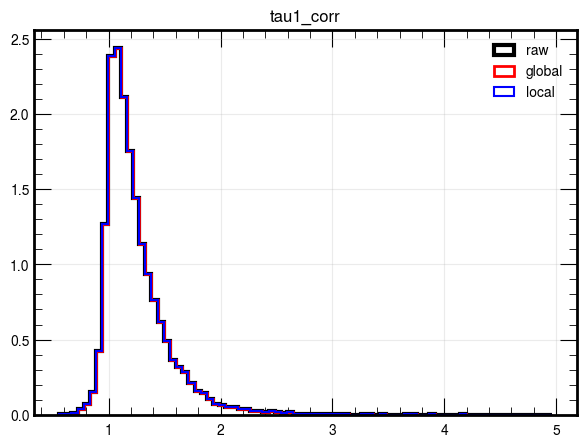

# Plot

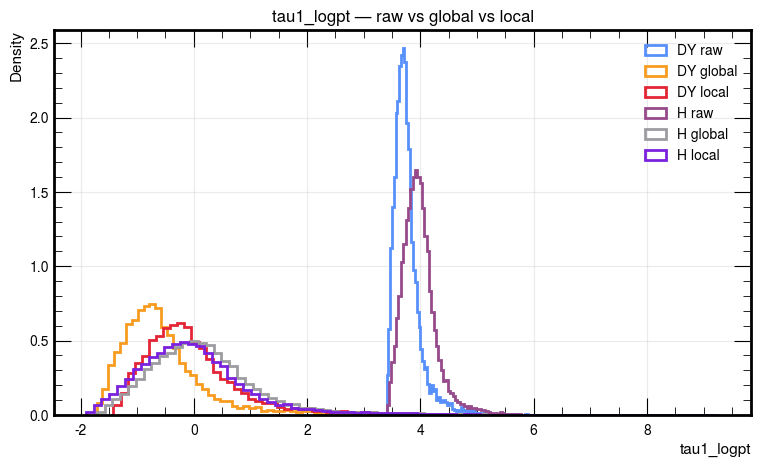

In [16]:
# all:
scalingUtils.plot_feature_raw_global_local(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    feature=train_cols[0],
    class_col=CLASS_COL,
    bins=80,
    density=True,
)

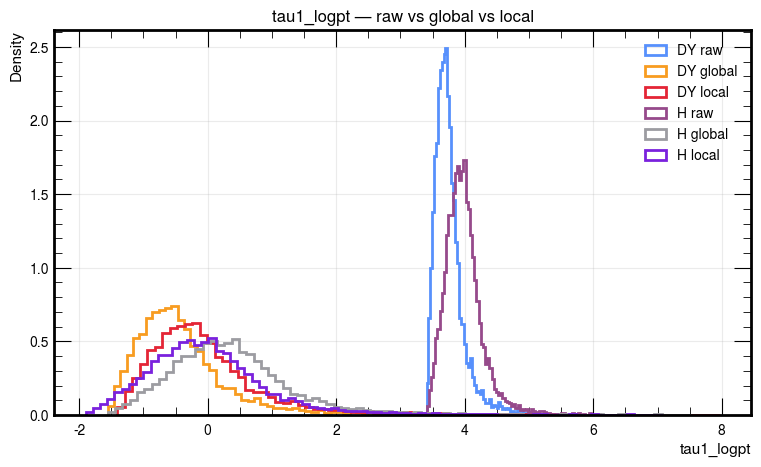

In [24]:
# balanced:
scalingUtils.plot_feature_raw_global_local(
    df_raw=df_bal_test_raw,
    df_global=df_bal_test_global,
    df_local=df_bal_test_local,
    feature=train_cols[0],
    class_col=CLASS_COL,
    bins=80,
    density=True,
)

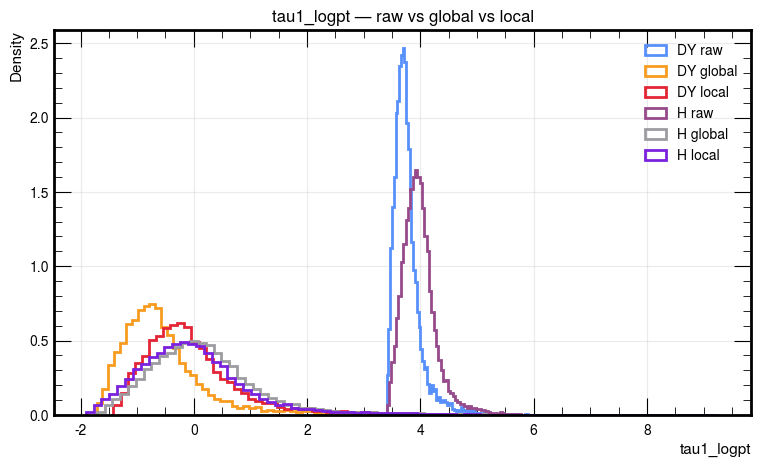

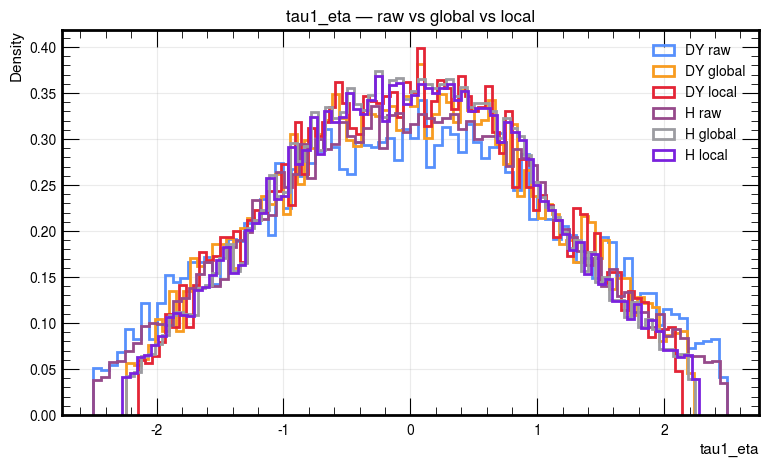

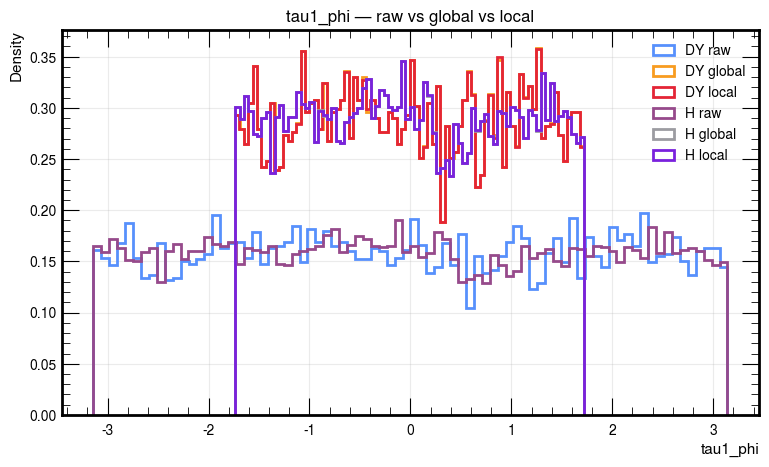

In [25]:
# Se voglio mostrare più features, cambio l'intervallo:
for feat in train_cols[:3]:
    scalingUtils.plot_feature_raw_global_local(
        df_raw=df_all_test_raw,
        df_global=df_all_test_global,
        df_local=df_all_test_local,
        feature=feat,
        class_col=CLASS_COL,
        bins=80,
        density=True,
    )

# Trainings
- Uso come test il sample unbalanced (ALL)

In [26]:
import importlib
import fm.scaling_utils as ScalingUtils
importlib.reload(scalingUtils)

<module 'fm.scaling_utils' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/scaling_utils.py'>

In [27]:
feature_1 = "tau1_logpt"

res_feat_global = scalingUtils.train_one_feature_variant(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    feature=feature_1,
    variant="global",
    train_cols=train_cols,
    y_cols=y_cols,
)

res_feat_local = scalingUtils.train_one_feature_variant(
    df_train=df_all_train,
    df_val=df_all_val,
    df_test=df_all_test,
    feature=feature_1,
    variant="local",
    train_cols=train_cols,
    y_cols=y_cols,
)

[tau1_logpt | global | ep    1] train=2.018611  val=1.102011  best=1.102011  bad=0/30


KeyboardInterrupt: 

In [60]:
res_feat_local_pred = dict(res_feat_local)
res_feat_local_pred["scalers"] = dict(res_feat_local["scalers"])
res_feat_local_pred["scalers"]["mode"] = "X_LOCAL__Y_LOCAL"

# Predictions:
df_pred_feat_local = model.predict_tau_corr_auto(
    df=df_all_test_feat_local,
    res=res_feat_local_pred,
    train_cols=train_cols,
    y_cols=y_cols,
)

In [61]:
m_feat_global = physics.inv_mass_two_taus_corrected_ratio(
    df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau1_eta"].to_numpy(),
    df_all_test["tau1_phi"].to_numpy(),
    df_all_test["tau1_mass"].to_numpy(),
    df_pred_feat_global["tau1_corr_pred"].to_numpy(),
    df_all_test["tau2_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau2_eta"].to_numpy(),
    df_all_test["tau2_phi"].to_numpy(),
    df_all_test["tau2_mass"].to_numpy(),
    df_pred_feat_global["tau2_corr_pred"].to_numpy(),
)

m_feat_local = physics.inv_mass_two_taus_corrected_ratio(
    df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau1_eta"].to_numpy(),
    df_all_test["tau1_phi"].to_numpy(),
    df_all_test["tau1_mass"].to_numpy(),
    df_pred_feat_local["tau1_corr_pred"].to_numpy(),
    df_all_test["tau2_pt_reco_corrPNet"].to_numpy(),
    df_all_test["tau2_eta"].to_numpy(),
    df_all_test["tau2_phi"].to_numpy(),
    df_all_test["tau2_mass"].to_numpy(),
    df_pred_feat_local["tau2_corr_pred"].to_numpy(),
)

In [62]:
# Separo:
mask_dy = (df_all_test["class"] == 0).to_numpy()
mask_h  = (df_all_test["class"] == 1).to_numpy()

m_feat_global_dy = m_feat_global[mask_dy]
m_feat_global_h  = m_feat_global[mask_h]

m_feat_local_dy = m_feat_local[mask_dy]
m_feat_local_h  = m_feat_local[mask_h]

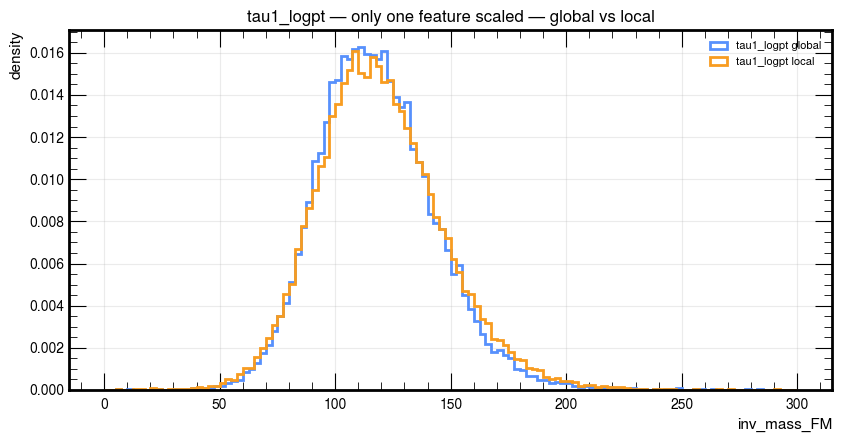

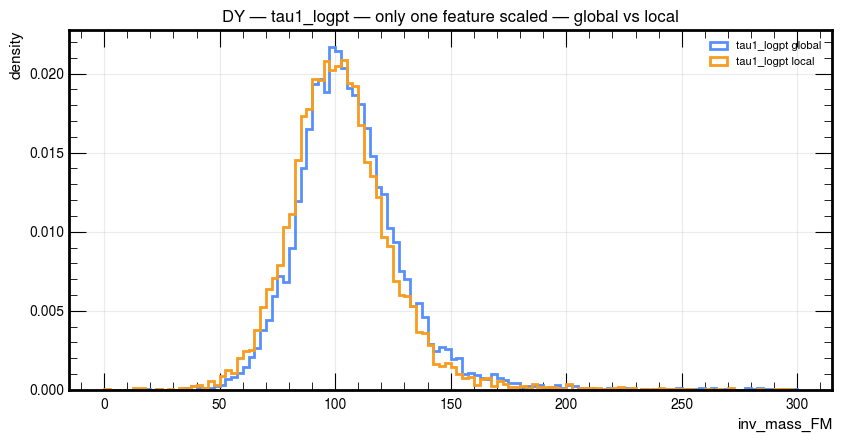

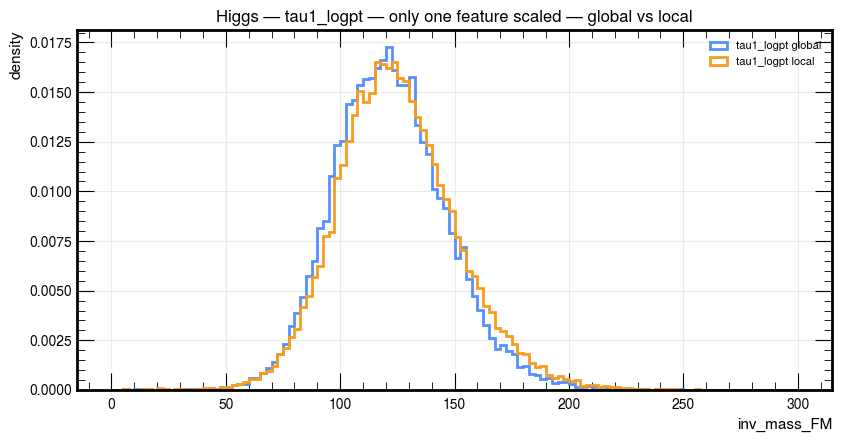

In [63]:
massesPlots.plot_mass_overlay(
    {
        f"{feature} global": m_feat_global,
        f"{feature} local": m_feat_local,
    },
    title=f"{feature_1} — only one feature scaled — global vs local",
    bins=120,
    range_=(0, 300),
    density=True,
)

mask_dy = (df_all_test["class"] == 0).to_numpy()

massesPlots.plot_mass_overlay(
    {
        f"{feature_1} global": m_feat_global[mask_dy],
        f"{feature_1} local": m_feat_local[mask_dy],
    },
    title=f"DY — {feature_1} — only one feature scaled — global vs local",
    bins=120,
    range_=(0, 300),
    density=True,
)

mask_h = (df_all_test["class"] == 1).to_numpy()

massesPlots.plot_mass_overlay(
    {
        f"{feature_1} global": m_feat_global[mask_h],
        f"{feature_1} local": m_feat_local[mask_h],
    },
    title=f"Higgs — {feature_1} — only one feature scaled — global vs local",
    bins=120,
    range_=(0, 300),
    density=True,
)

# Comparison

In [28]:
# Scelgo un mode e prendo i risultati unbalanced 
BASELINE_MODE = "X_LOCAL__Y_LOCAL"   

m_dy_npz = np.load("../results/masses/masses_unbal_nonflat_mse_dy.npz")
m_h_npz  = np.load("../results/masses/masses_unbal_nonflat_mse_h.npz")

m_baseline_dy = m_dy_npz[BASELINE_MODE]
m_baseline_h  = m_h_npz[BASELINE_MODE]

# check:
print("DY baseline:", m_baseline_dy.shape)
print("H baseline:", m_baseline_h.shape)

DY baseline: (8244,)
H baseline: (25492,)


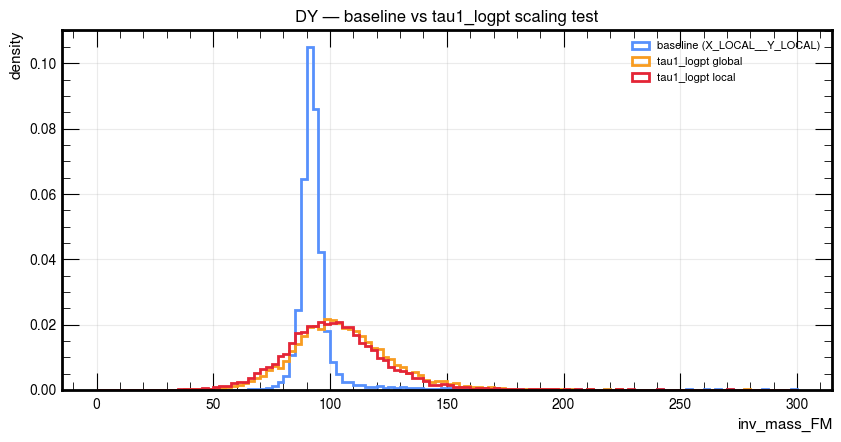

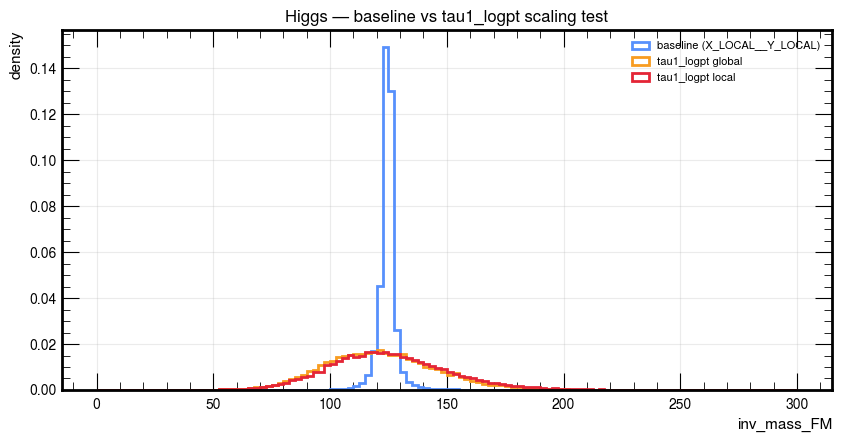

In [76]:
massesPlots.plot_mass_overlay(
    {
        f"baseline ({BASELINE_MODE})": m_baseline_dy,
        f"{feature_1} global": m_feat_global_dy,
        f"{feature_1} local": m_feat_local_dy,
    },
    title=f"DY — baseline vs {feature_1} scaling test",
    bins=120,
    range_=(0, 300),
    density=True,
)

massesPlots.plot_mass_overlay(
    {
        f"baseline ({BASELINE_MODE})": m_baseline_h,
        f"{feature_1} global": m_feat_global_h,
        f"{feature_1} local": m_feat_local_h,
    },
    title=f"Higgs — baseline vs {feature_1} scaling test",
    bins=120,
    range_=(0, 300),
    density=True,
)

# All X Variables

In [11]:
import fm.scaling_utils as ScalingUtils
import importlib
importlib.reload(scalingUtils)

<module 'fm.scaling_utils' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/scaling_utils.py'>

## Plot variabili pre/post scaling

tau1:



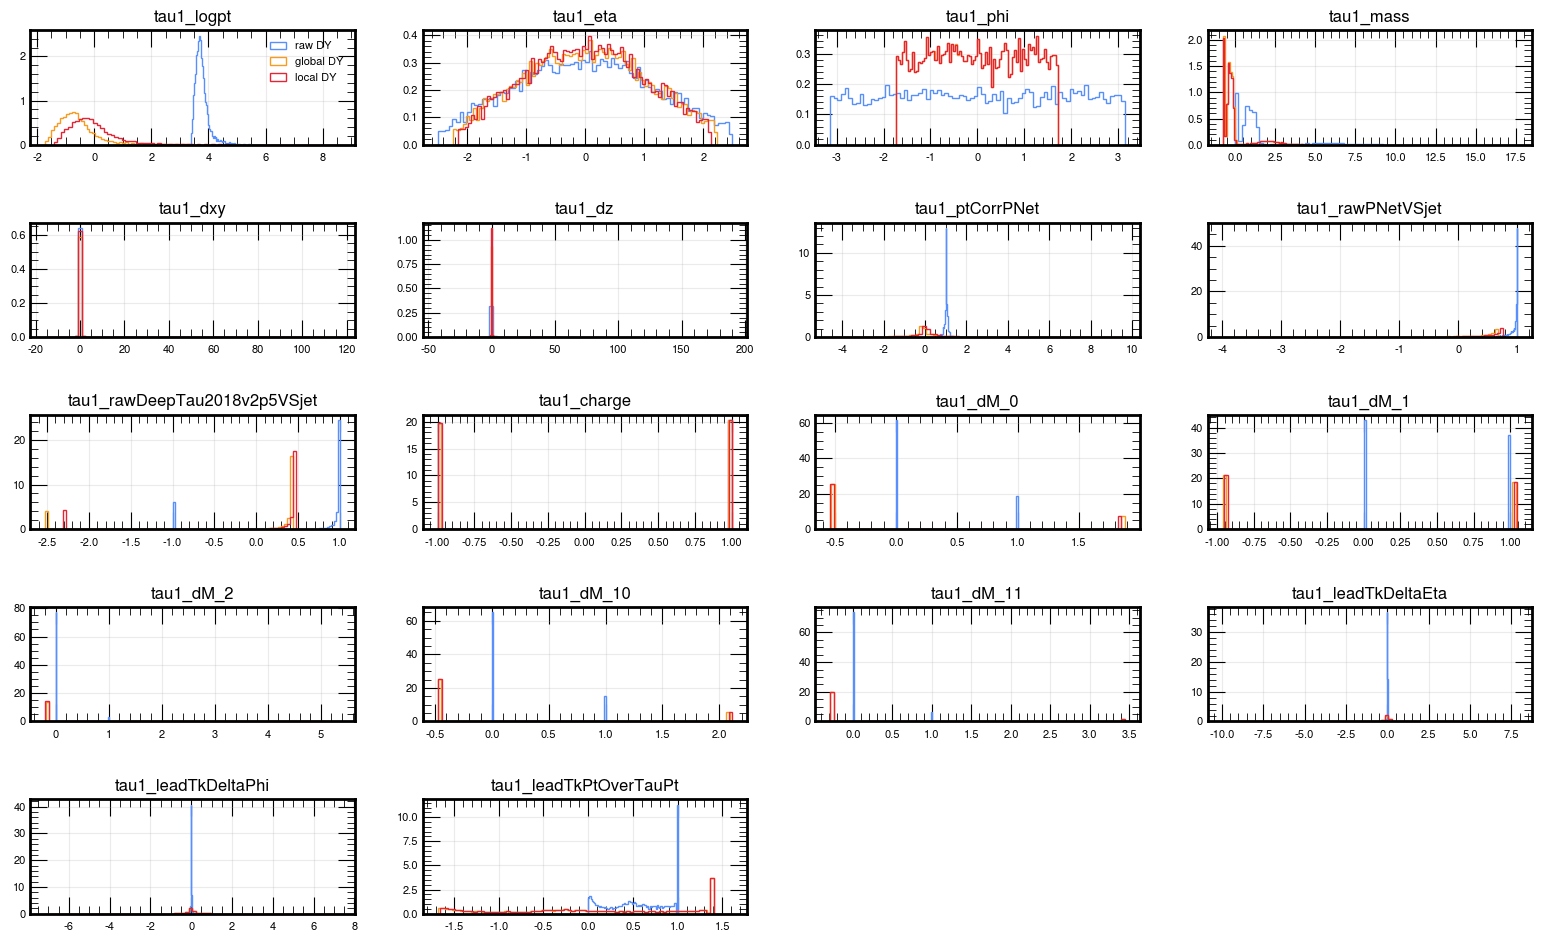

tau2:



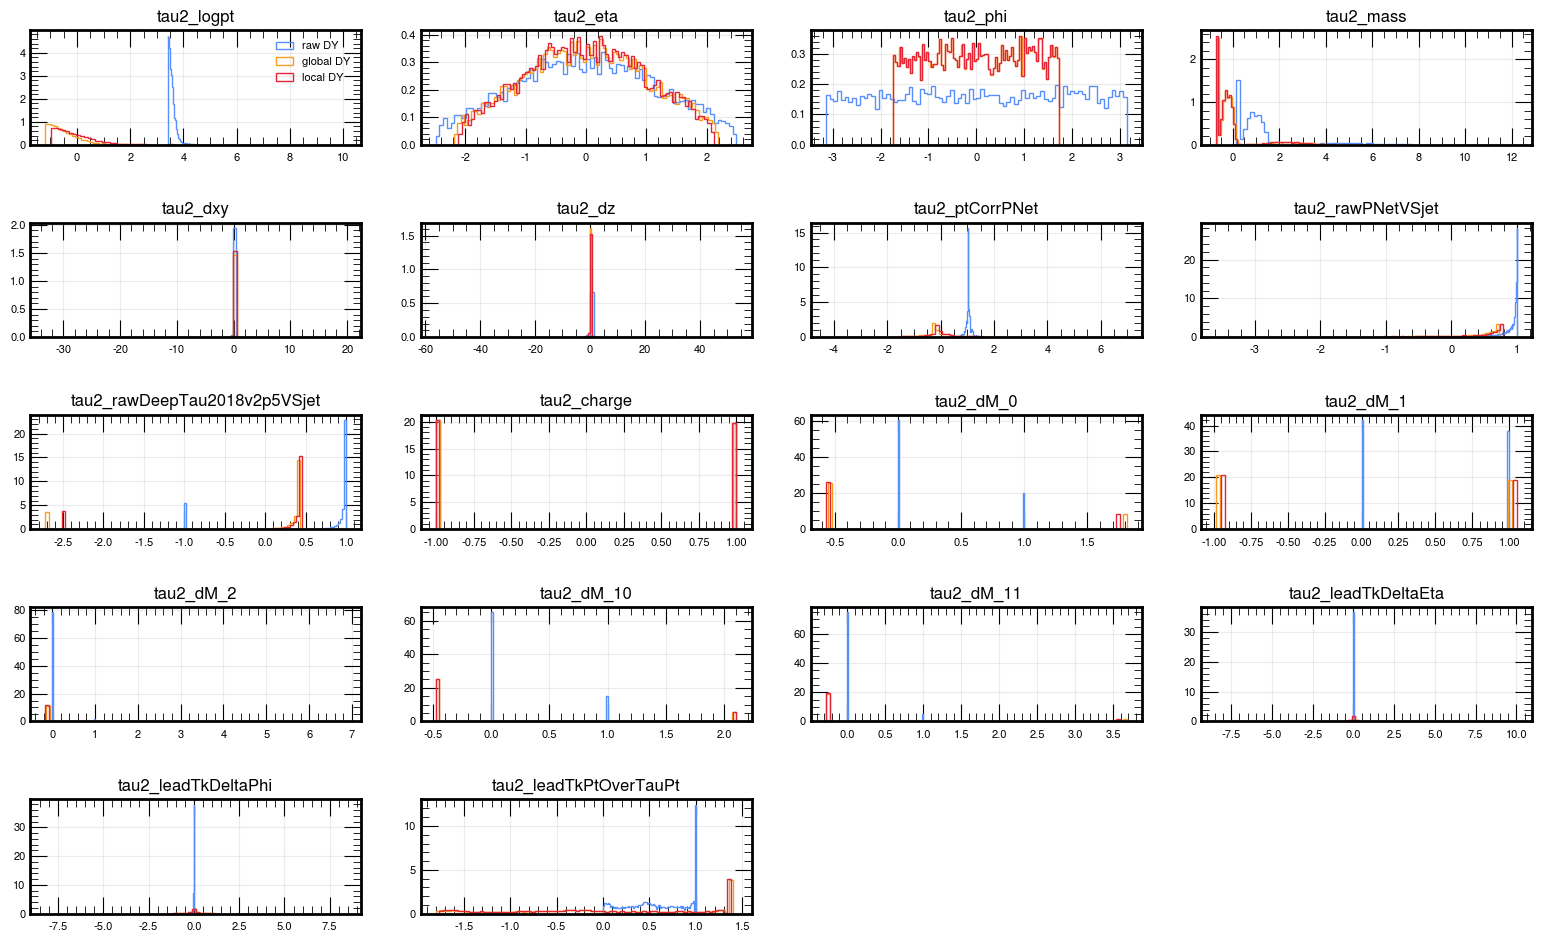

MET:


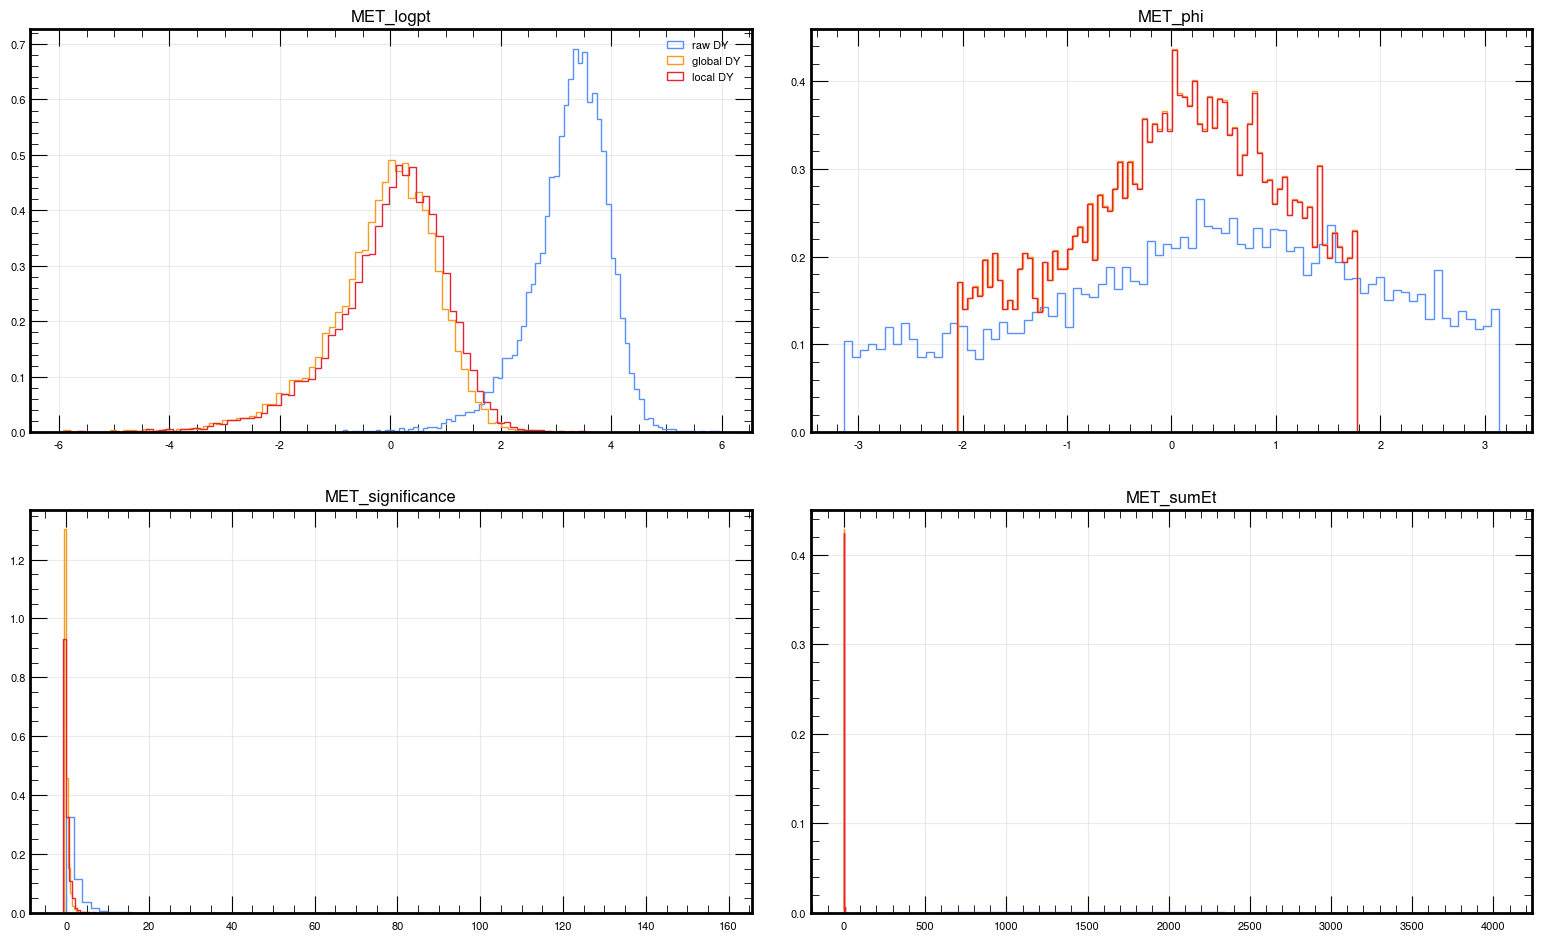

Jet:


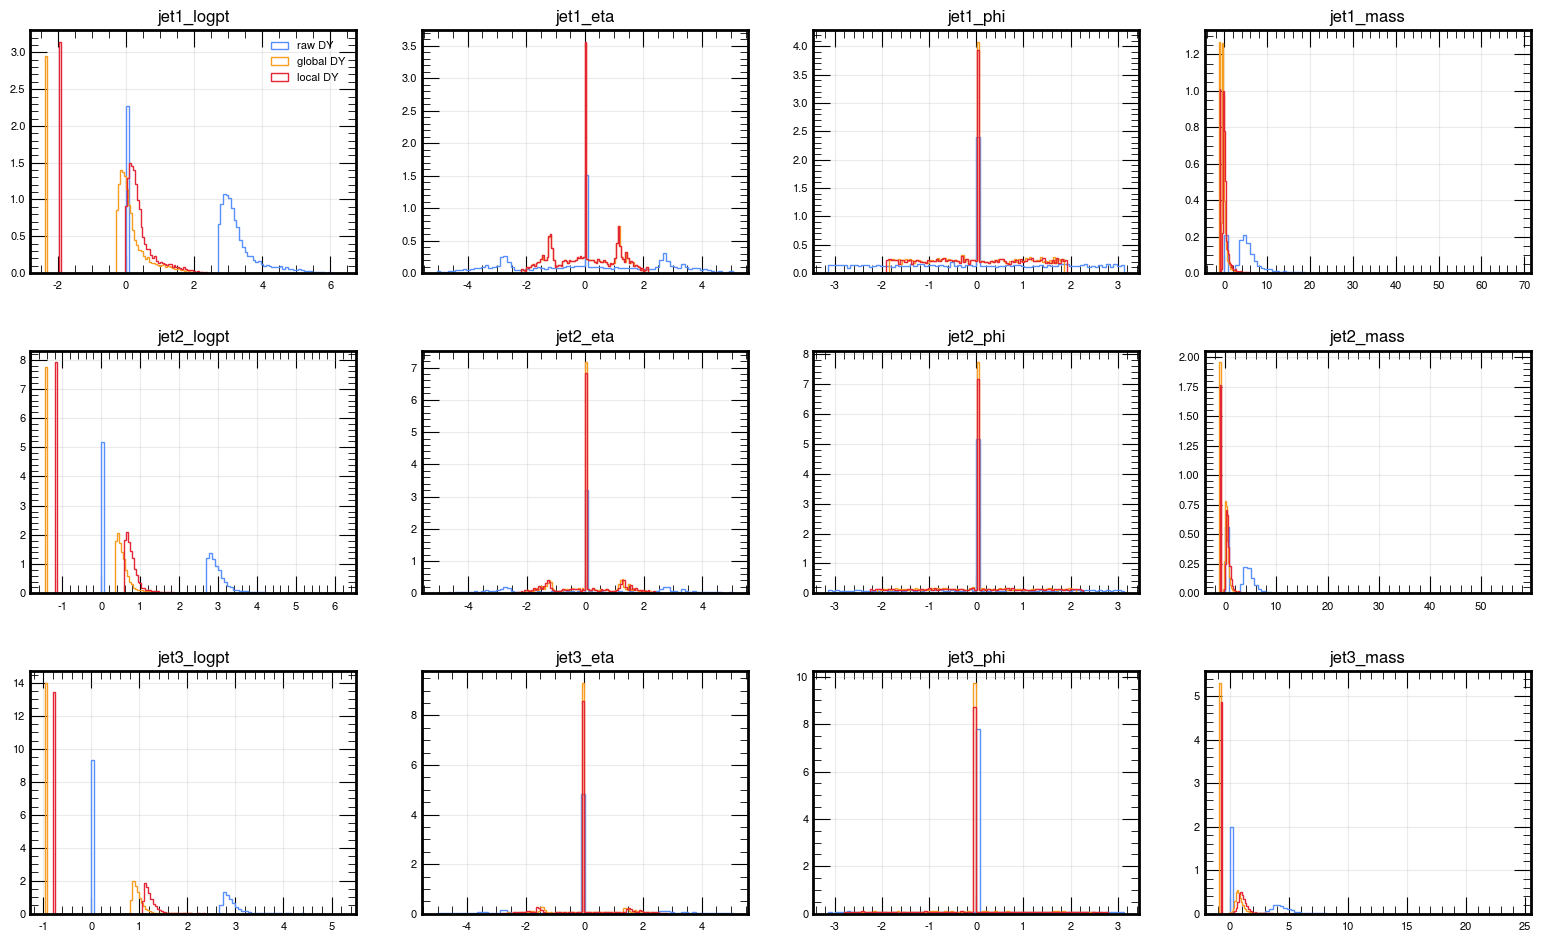

In [29]:
print("tau1:\n")
scalingUtils.plot_feature_grid_raw_global_local(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=tau1_cols,
    class_col="class",
    ncols=4,
)
print("tau2:\n")
scalingUtils.plot_feature_grid_raw_global_local(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=tau2_cols,
    class_col="class",
    ncols=4,
)
print("MET:")
scalingUtils.plot_feature_grid_raw_global_local(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=met_cols,
    class_col="class",
    ncols=2,
)
print("Jet:")
scalingUtils.plot_feature_grid_raw_global_local(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=jet_cols,
    class_col="class",
    ncols=4,
)

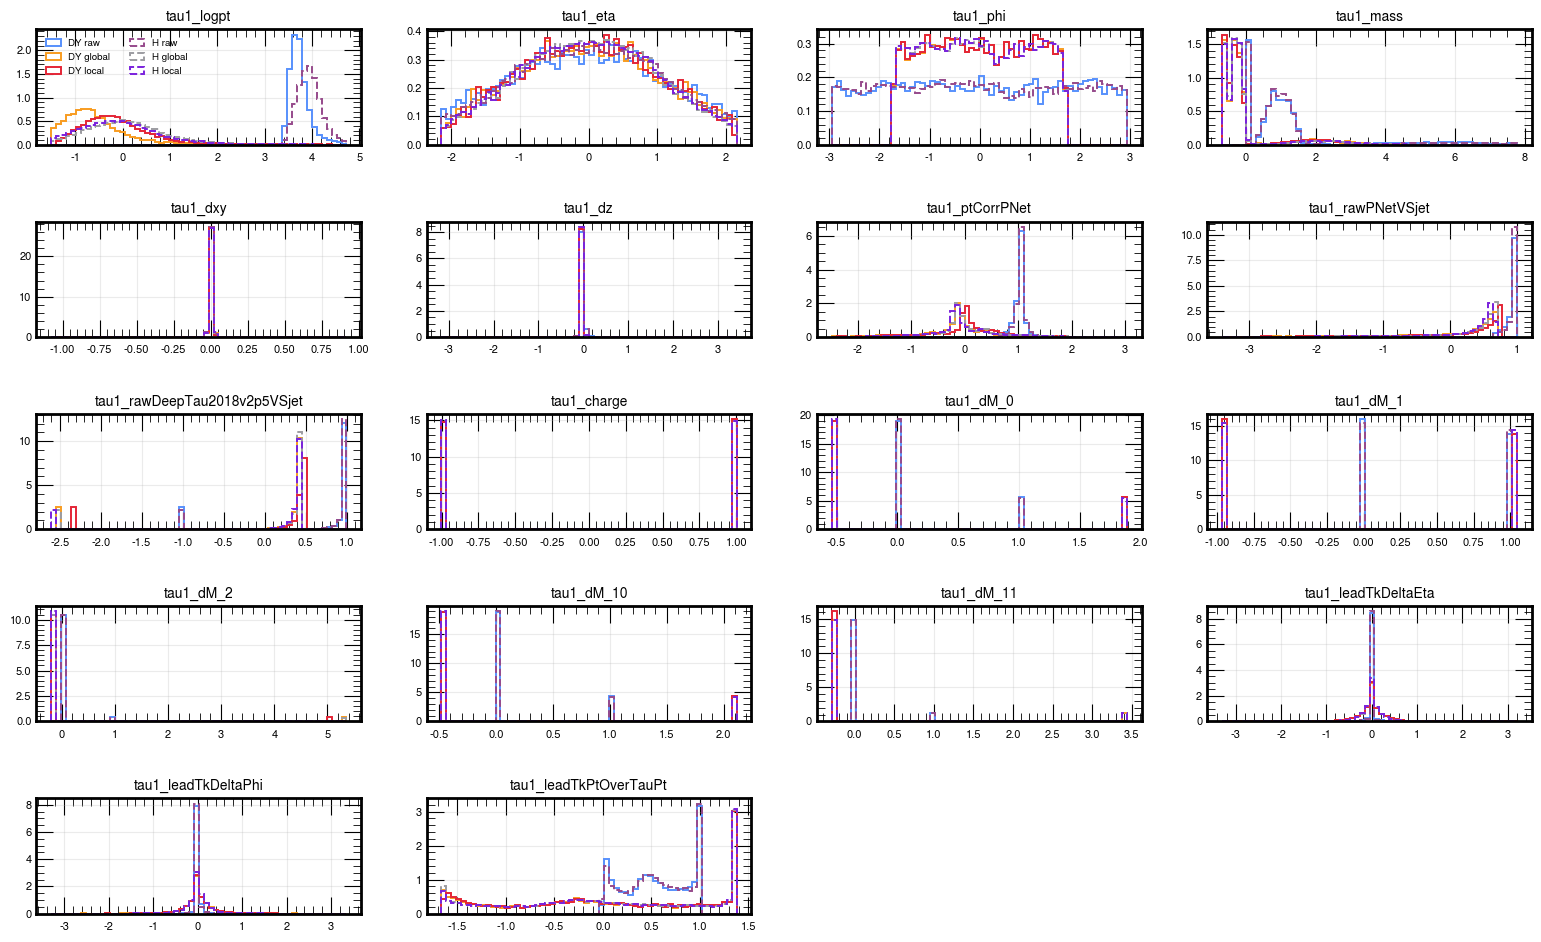

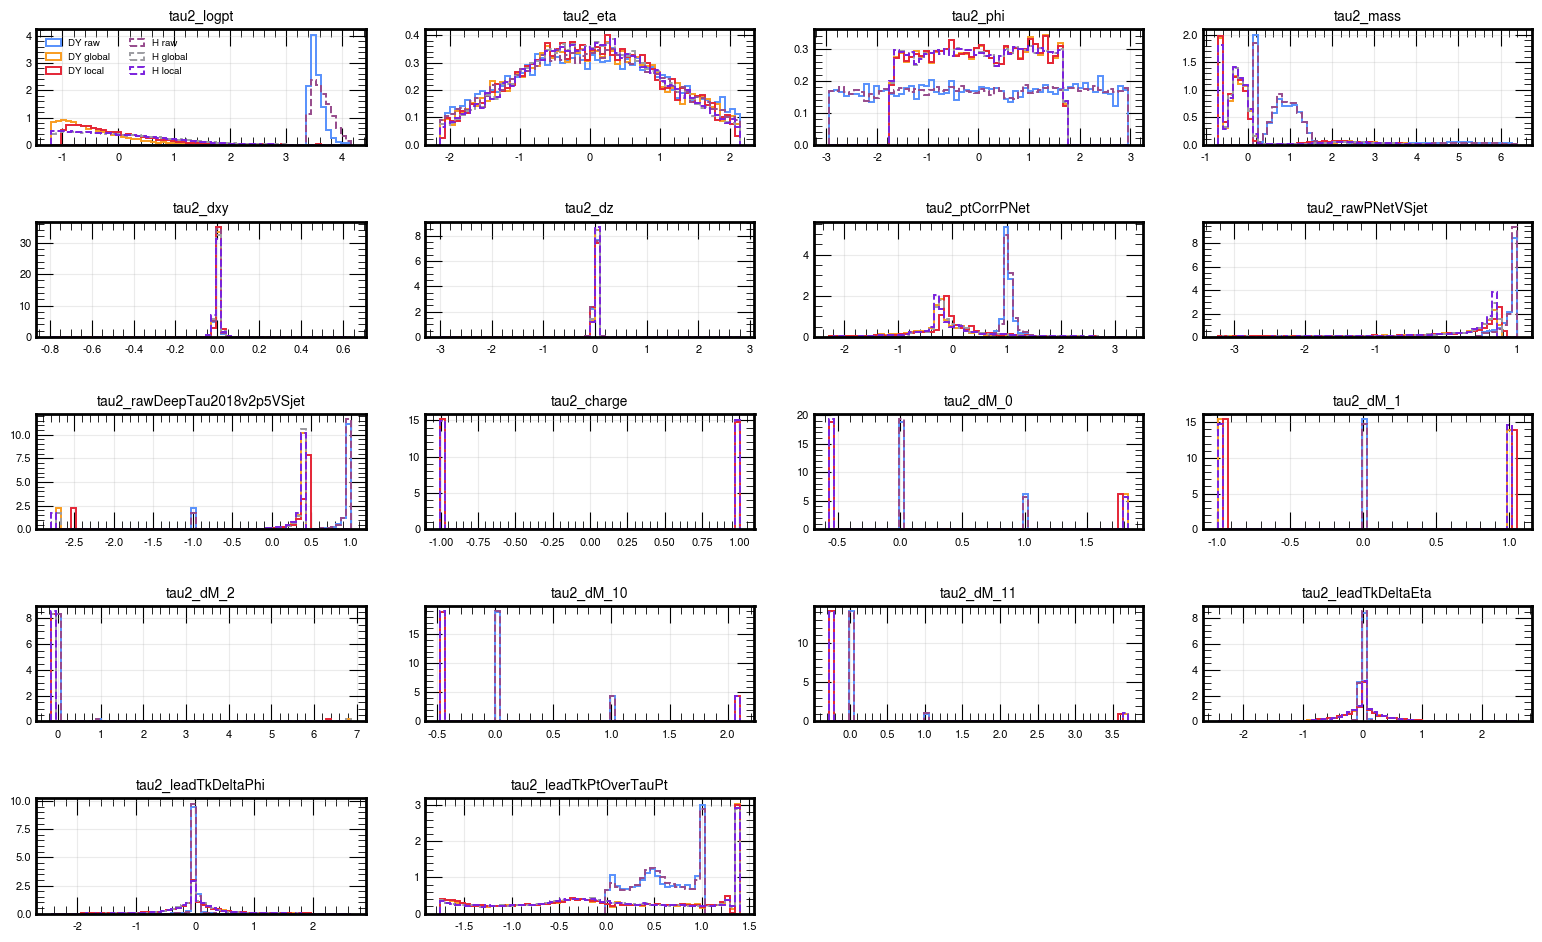

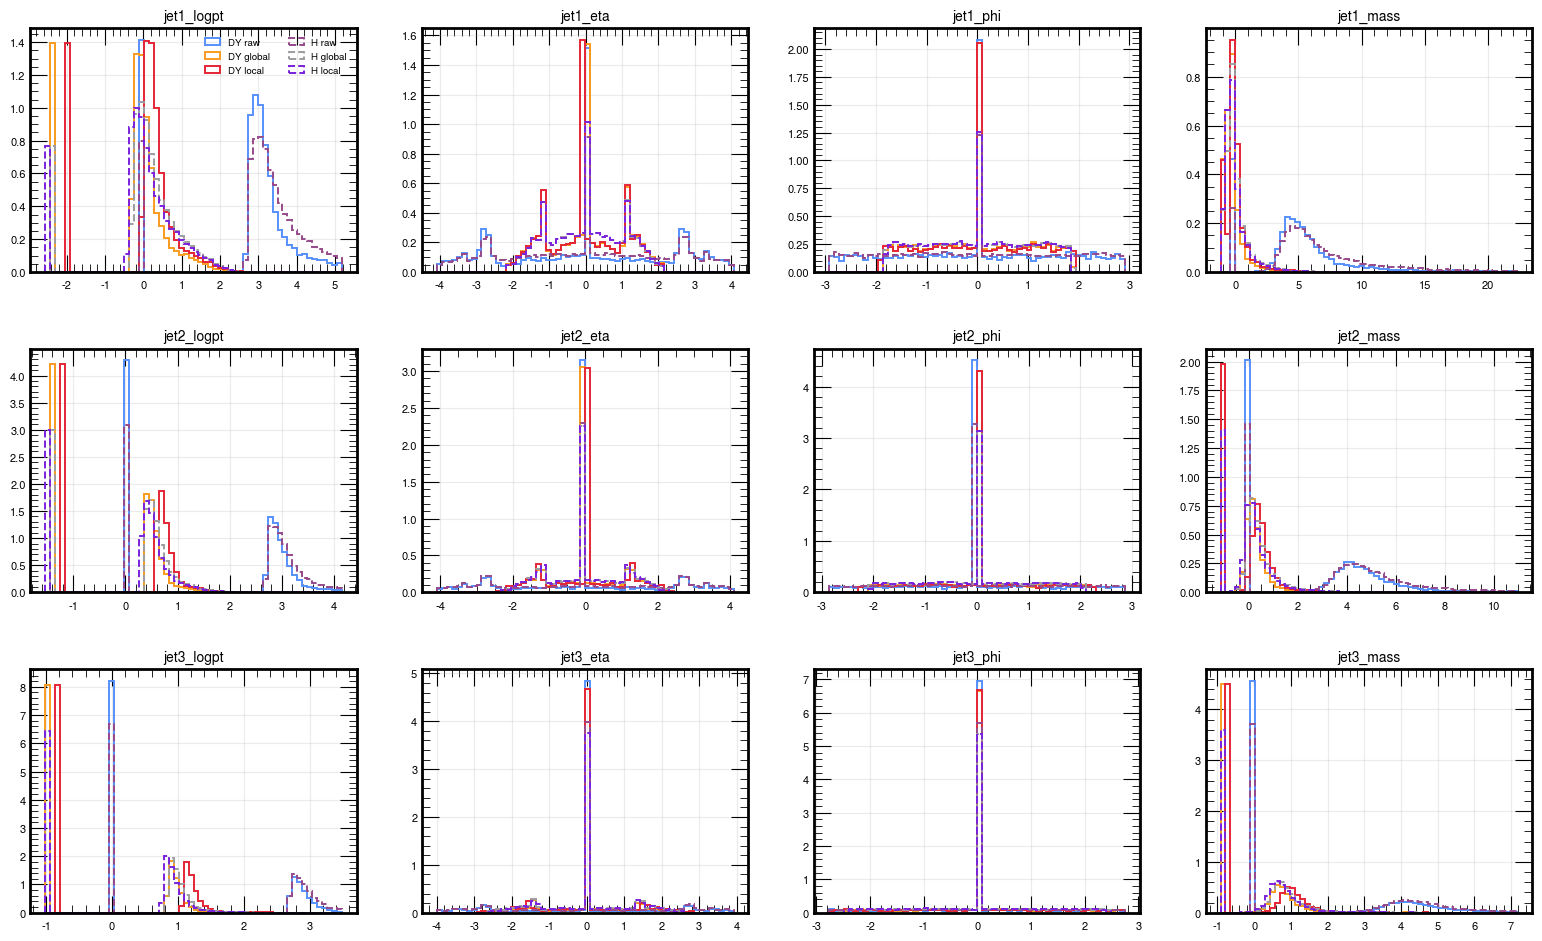

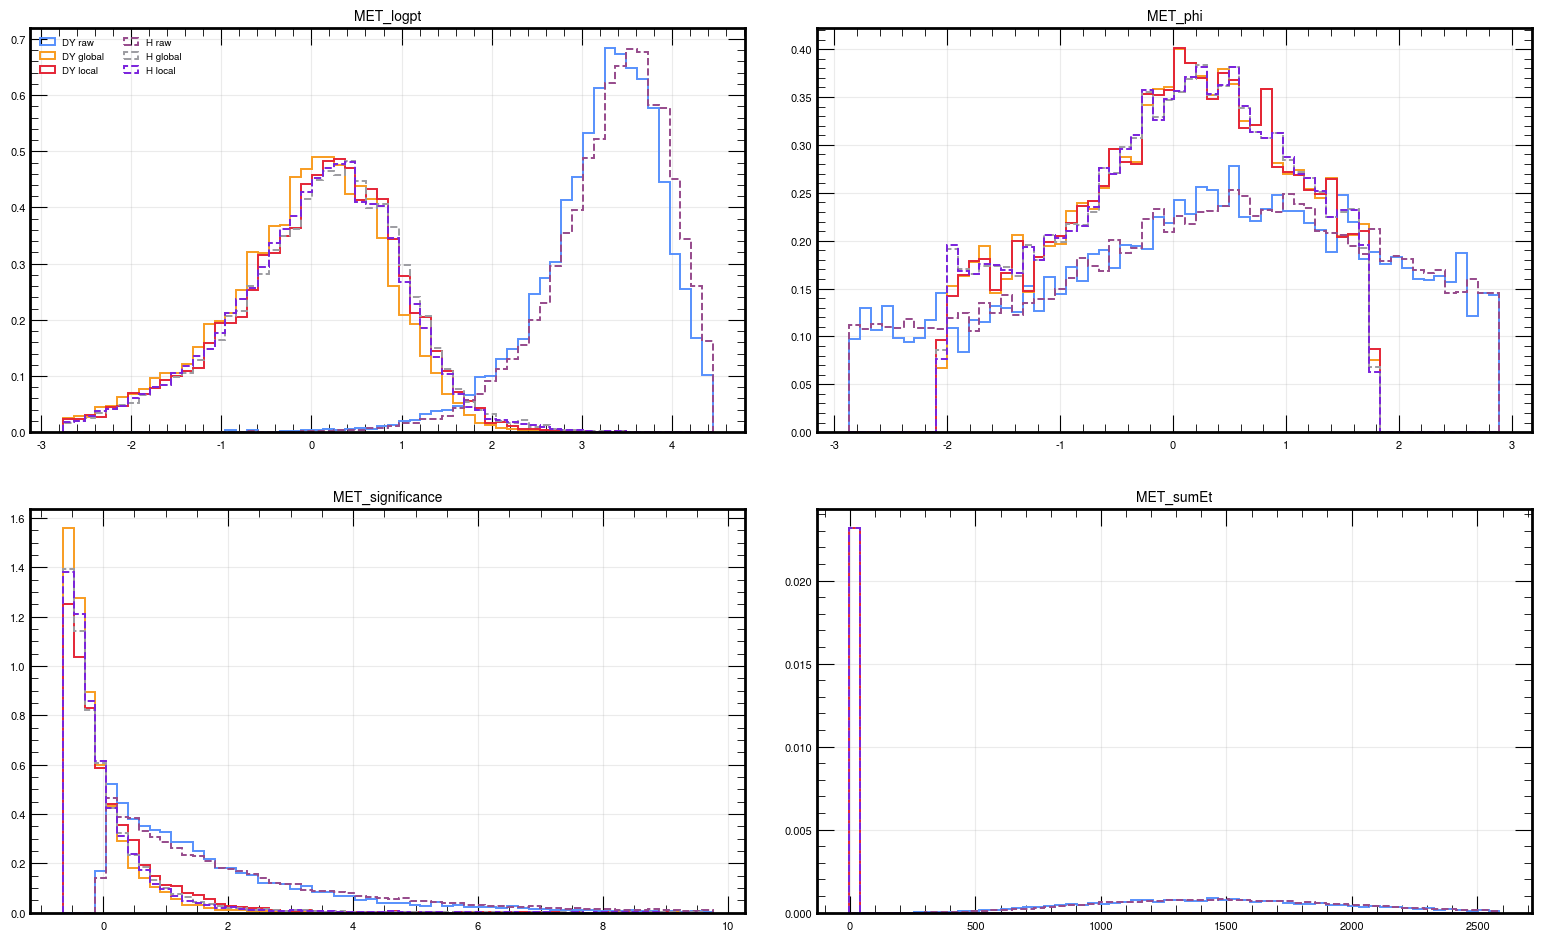

In [30]:
scalingUtils.plot_feature_grid_both_classes(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=tau1_cols,
    class_col="class",
    ncols=4,
    figsize=(16, 10),
)

scalingUtils.plot_feature_grid_both_classes(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=tau2_cols,
    class_col="class",
    ncols=4,
    figsize=(16, 10),
)

scalingUtils.plot_feature_grid_both_classes(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=jet_cols,
    class_col="class",
    ncols=4,
    figsize=(16, 10),
)

scalingUtils.plot_feature_grid_both_classes(
    df_raw=df_all_test_raw,
    df_global=df_all_test_global,
    df_local=df_all_test_local,
    features=met_cols,
    class_col="class",
    ncols=2,
    figsize=(16, 10),
)

In [32]:
# dict per salvare i risultati:
results_feature_scan = {}

# training solo local
for feat in train_cols:

    print("\n" + "="*80)
    print(f"TRAINING FEATURE: {feat}")
    print("="*80)

    res_local = scalingUtils.train_one_feature_variant(
        df_train=df_all_train,
        df_val=df_all_val,
        df_test=df_all_test,
        feature=feat,
        variant="local",
        train_cols=train_cols,
        y_cols=y_cols,
    )

    results_feature_scan[feat] = {
        "local": res_local,
    }


TRAINING FEATURE: tau1_logpt
[tau1_logpt | local | ep    1] train=2.492311  val=1.128040  best=1.128040  bad=0/30
[tau1_logpt | local | ep   10] train=1.016101  val=0.973057  best=0.973057  bad=0/30
[tau1_logpt | local | ep   20] train=0.787080  val=0.828993  best=0.755979  bad=1/30
[tau1_logpt | local | ep   30] train=0.681781  val=0.687564  best=0.653953  bad=3/30
[tau1_logpt | local | ep   40] train=0.645873  val=0.594421  best=0.591917  bad=3/30
[tau1_logpt | local | ep   50] train=0.627788  val=0.657341  best=0.568708  bad=1/30
[tau1_logpt | local | ep   60] train=0.582278  val=0.663785  best=0.536811  bad=6/30
[tau1_logpt | local | ep   70] train=0.567132  val=0.517206  best=0.517206  bad=0/30
[tau1_logpt | local | ep   80] train=0.526556  val=0.502156  best=0.502156  bad=0/30
[tau1_logpt | local | ep   90] train=0.538464  val=0.510885  best=0.502156  bad=10/30
[tau1_logpt | local | ep  100] train=0.495415  val=0.496046  best=0.482668  bad=1/30
[tau1_logpt | local | ep  110] tra

In [33]:
joblib.dump(results_feature_scan, "results_feature_scan.pkl")

['results_feature_scan.pkl']

In [34]:
# Predictions:
preds_feature_scan = {}

for feat, res_pair in results_feature_scan.items():

    print("\n" + "="*80)
    print(f"PREDICTIONS FEATURE: {feat}")
    print("="*80)

    res_local = res_pair["local"]
    df_test_local = res_local["df_splits_scaled"][2]

    res_local_pred = dict(res_local)
    res_local_pred["scalers"] = dict(res_local["scalers"])
    res_local_pred["scalers"]["mode"] = "X_NONE__Y_NONE"

    df_pred_local = model.predict_tau_corr_auto(
        df=df_test_local,
        res=res_local_pred,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_feature_scan[feat] = {
        "local": df_pred_local,
    }


PREDICTIONS FEATURE: tau1_logpt

PREDICTIONS FEATURE: tau1_eta

PREDICTIONS FEATURE: tau1_phi

PREDICTIONS FEATURE: tau1_mass

PREDICTIONS FEATURE: tau1_dxy

PREDICTIONS FEATURE: tau1_dz

PREDICTIONS FEATURE: tau1_ptCorrPNet

PREDICTIONS FEATURE: tau1_rawPNetVSjet

PREDICTIONS FEATURE: tau1_rawDeepTau2018v2p5VSjet

PREDICTIONS FEATURE: tau1_charge

PREDICTIONS FEATURE: tau1_dM_0

PREDICTIONS FEATURE: tau1_dM_1

PREDICTIONS FEATURE: tau1_dM_2

PREDICTIONS FEATURE: tau1_dM_10

PREDICTIONS FEATURE: tau1_dM_11

PREDICTIONS FEATURE: tau1_leadTkDeltaEta

PREDICTIONS FEATURE: tau1_leadTkDeltaPhi

PREDICTIONS FEATURE: tau1_leadTkPtOverTauPt

PREDICTIONS FEATURE: tau2_logpt

PREDICTIONS FEATURE: tau2_eta

PREDICTIONS FEATURE: tau2_phi

PREDICTIONS FEATURE: tau2_mass

PREDICTIONS FEATURE: tau2_dxy

PREDICTIONS FEATURE: tau2_dz

PREDICTIONS FEATURE: tau2_ptCorrPNet

PREDICTIONS FEATURE: tau2_rawPNetVSjet

PREDICTIONS FEATURE: tau2_rawDeepTau2018v2p5VSjet

PREDICTIONS FEATURE: tau2_charge

PREDIC

In [35]:
# Masses:
masses_feature_scan = {}
masses_feature_scan_dy = {}
masses_feature_scan_h = {}

mask_dy = (df_all_test["class"] == 0).to_numpy()
mask_h  = (df_all_test["class"] == 1).to_numpy()

for feat, pred_pair in preds_feature_scan.items():

    print("\n" + "="*80)
    print(f"MASSES FEATURE: {feat}")
    print("="*80)

    df_pred_local = pred_pair["local"]

    m_local = physics.inv_mass_two_taus_corrected_ratio(
        df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
        df_all_test["tau1_eta"].to_numpy(),
        df_all_test["tau1_phi"].to_numpy(),
        df_all_test["tau1_mass"].to_numpy(),
        df_pred_local["tau1_corr_pred"].to_numpy(),
        df_all_test["tau2_pt_reco_corrPNet"].to_numpy(),
        df_all_test["tau2_eta"].to_numpy(),
        df_all_test["tau2_phi"].to_numpy(),
        df_all_test["tau2_mass"].to_numpy(),
        df_pred_local["tau2_corr_pred"].to_numpy(),
    )

    masses_feature_scan[feat] = {
        "local": m_local,
    }

    masses_feature_scan_dy[feat] = {
        "local": m_local[mask_dy],
    }

    masses_feature_scan_h[feat] = {
        "local": m_local[mask_h],
    }


MASSES FEATURE: tau1_logpt

MASSES FEATURE: tau1_eta

MASSES FEATURE: tau1_phi

MASSES FEATURE: tau1_mass

MASSES FEATURE: tau1_dxy

MASSES FEATURE: tau1_dz

MASSES FEATURE: tau1_ptCorrPNet

MASSES FEATURE: tau1_rawPNetVSjet

MASSES FEATURE: tau1_rawDeepTau2018v2p5VSjet

MASSES FEATURE: tau1_charge

MASSES FEATURE: tau1_dM_0

MASSES FEATURE: tau1_dM_1

MASSES FEATURE: tau1_dM_2

MASSES FEATURE: tau1_dM_10

MASSES FEATURE: tau1_dM_11

MASSES FEATURE: tau1_leadTkDeltaEta

MASSES FEATURE: tau1_leadTkDeltaPhi

MASSES FEATURE: tau1_leadTkPtOverTauPt

MASSES FEATURE: tau2_logpt

MASSES FEATURE: tau2_eta

MASSES FEATURE: tau2_phi

MASSES FEATURE: tau2_mass

MASSES FEATURE: tau2_dxy

MASSES FEATURE: tau2_dz

MASSES FEATURE: tau2_ptCorrPNet

MASSES FEATURE: tau2_rawPNetVSjet

MASSES FEATURE: tau2_rawDeepTau2018v2p5VSjet

MASSES FEATURE: tau2_charge

MASSES FEATURE: tau2_dM_0

MASSES FEATURE: tau2_dM_1

MASSES FEATURE: tau2_dM_2

MASSES FEATURE: tau2_dM_10

MASSES FEATURE: tau2_dM_11

MASSES FE

In [36]:
# Confronto con il baseline:
# carico
BASELINE_MODE = "X_LOCAL__Y_LOCAL"

m_dy_npz = np.load("../results/masses/masses_unbal_nonflat_mse_dy.npz")
m_h_npz  = np.load("../results/masses/masses_unbal_nonflat_mse_h.npz")

m_baseline_dy = m_dy_npz[BASELINE_MODE]
m_baseline_h  = m_h_npz[BASELINE_MODE]

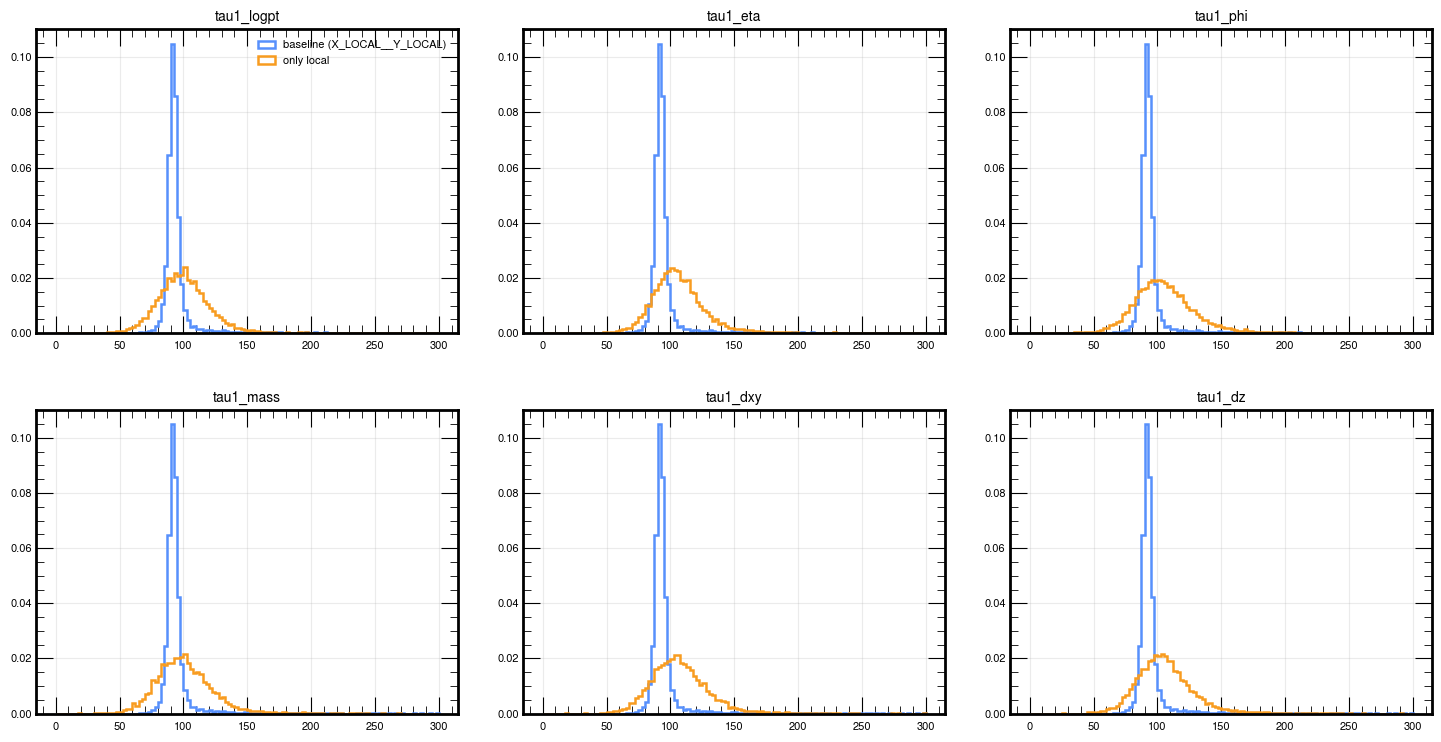

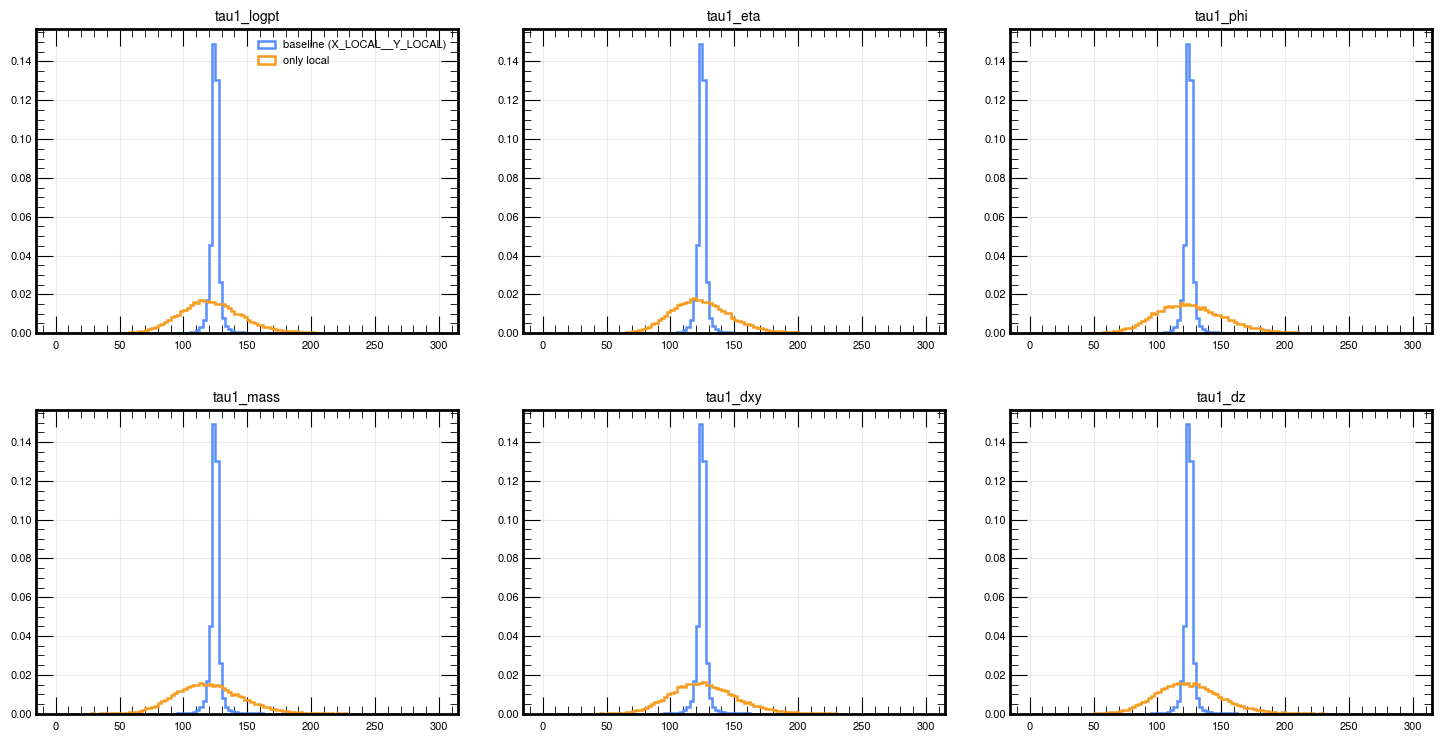

In [37]:
features_to_plot = train_cols[:6]

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_dy,
    baseline_mass=m_baseline_dy,
    features=features_to_plot,
    label_feature="only local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    bins=120,
    range_=(0, 300),
    density=True,
    ncols=3,
    figsize=(15, 8),
)

features_to_plot = train_cols[:6]

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_h,
    baseline_mass=m_baseline_h,
    features=features_to_plot,
    label_feature="only local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    bins=120,
    range_=(0, 300),
    density=True,
    ncols=3,
    figsize=(15, 8),
)

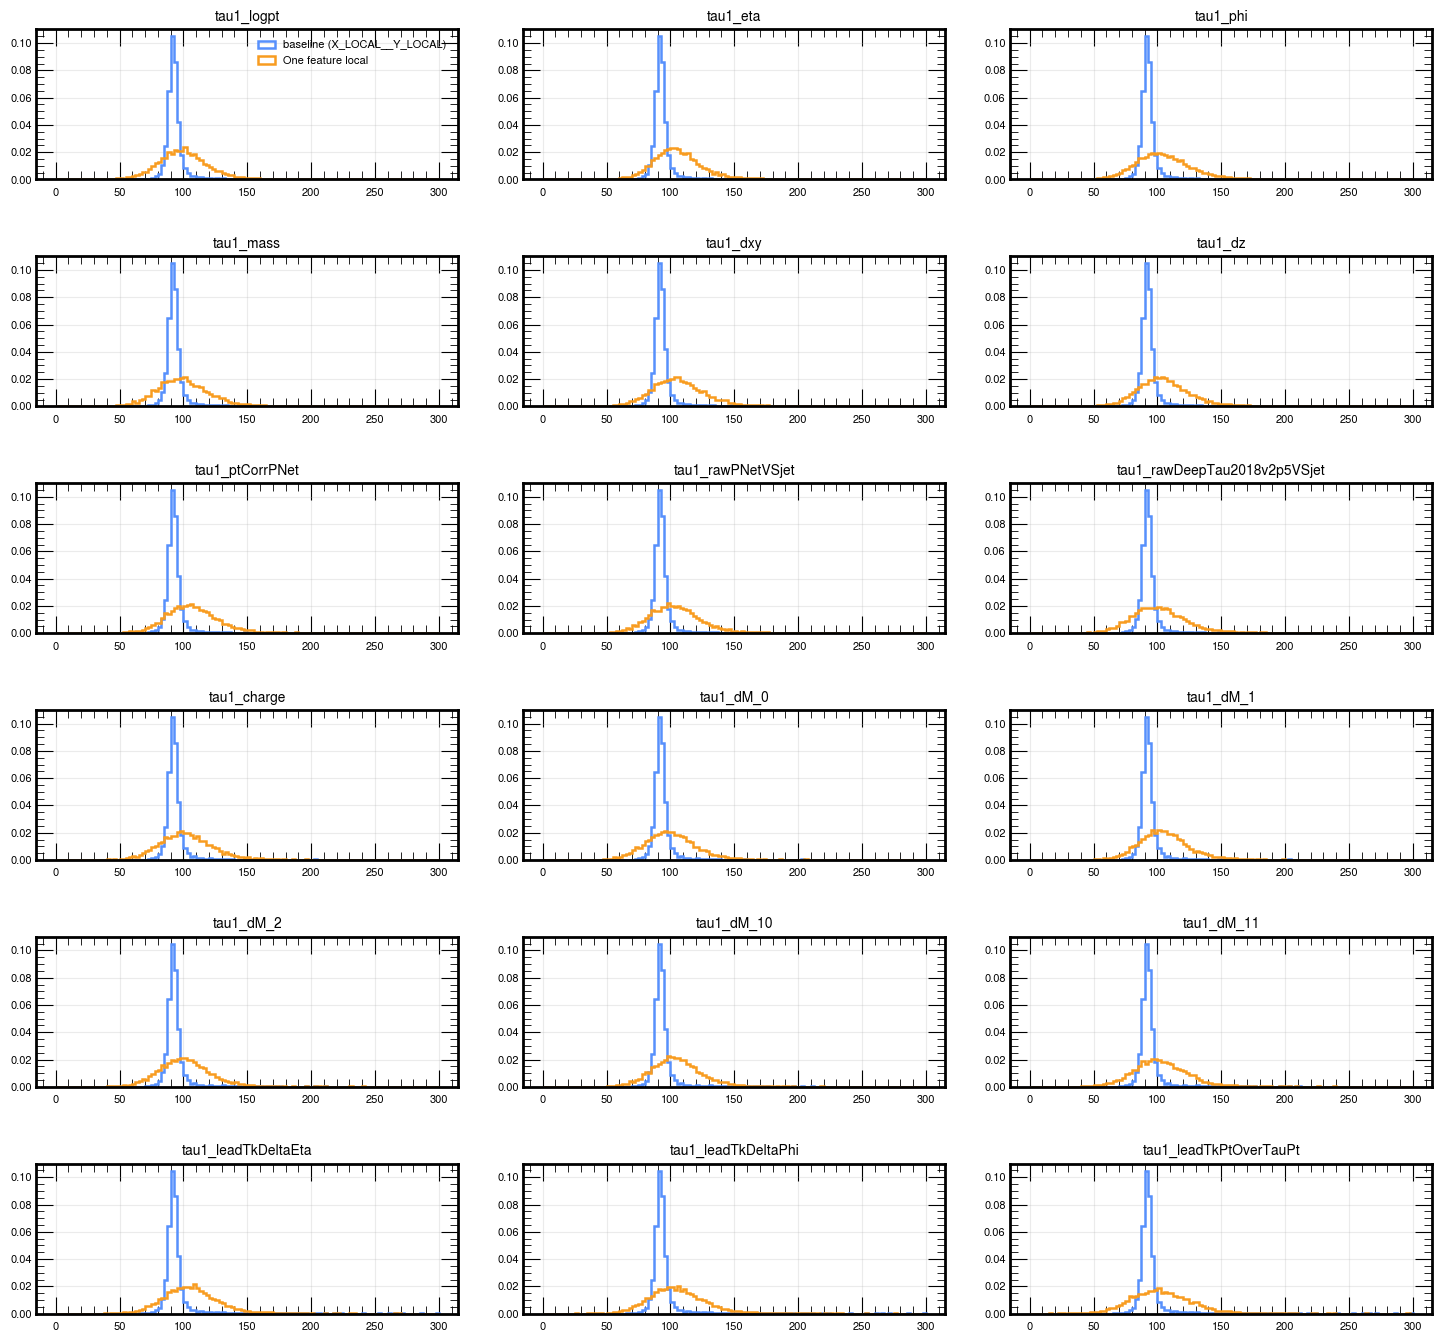

In [38]:
scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_dy,
    baseline_mass=m_baseline_dy,
    features=tau1_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=3,
    figsize=(15, 14),
)

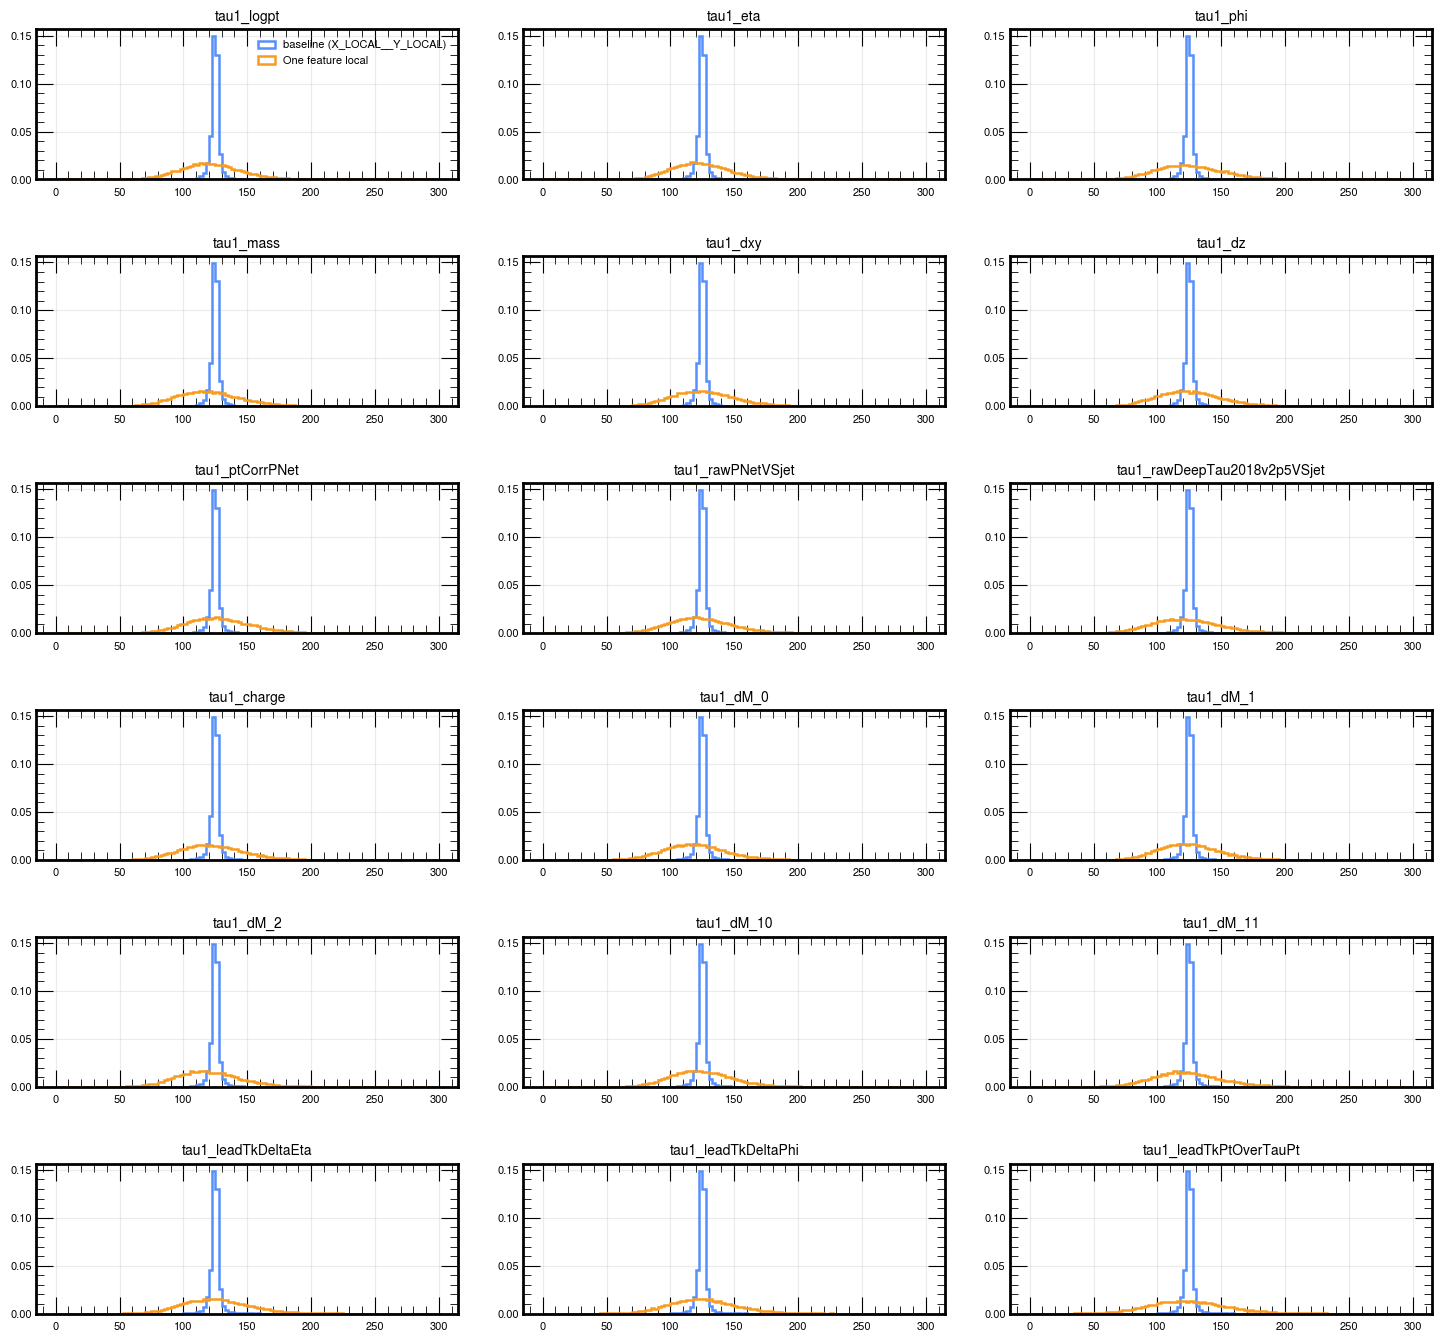

In [39]:
scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_h,
    baseline_mass=m_baseline_h,
    features=tau1_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=3,
    figsize=(15, 14),
)

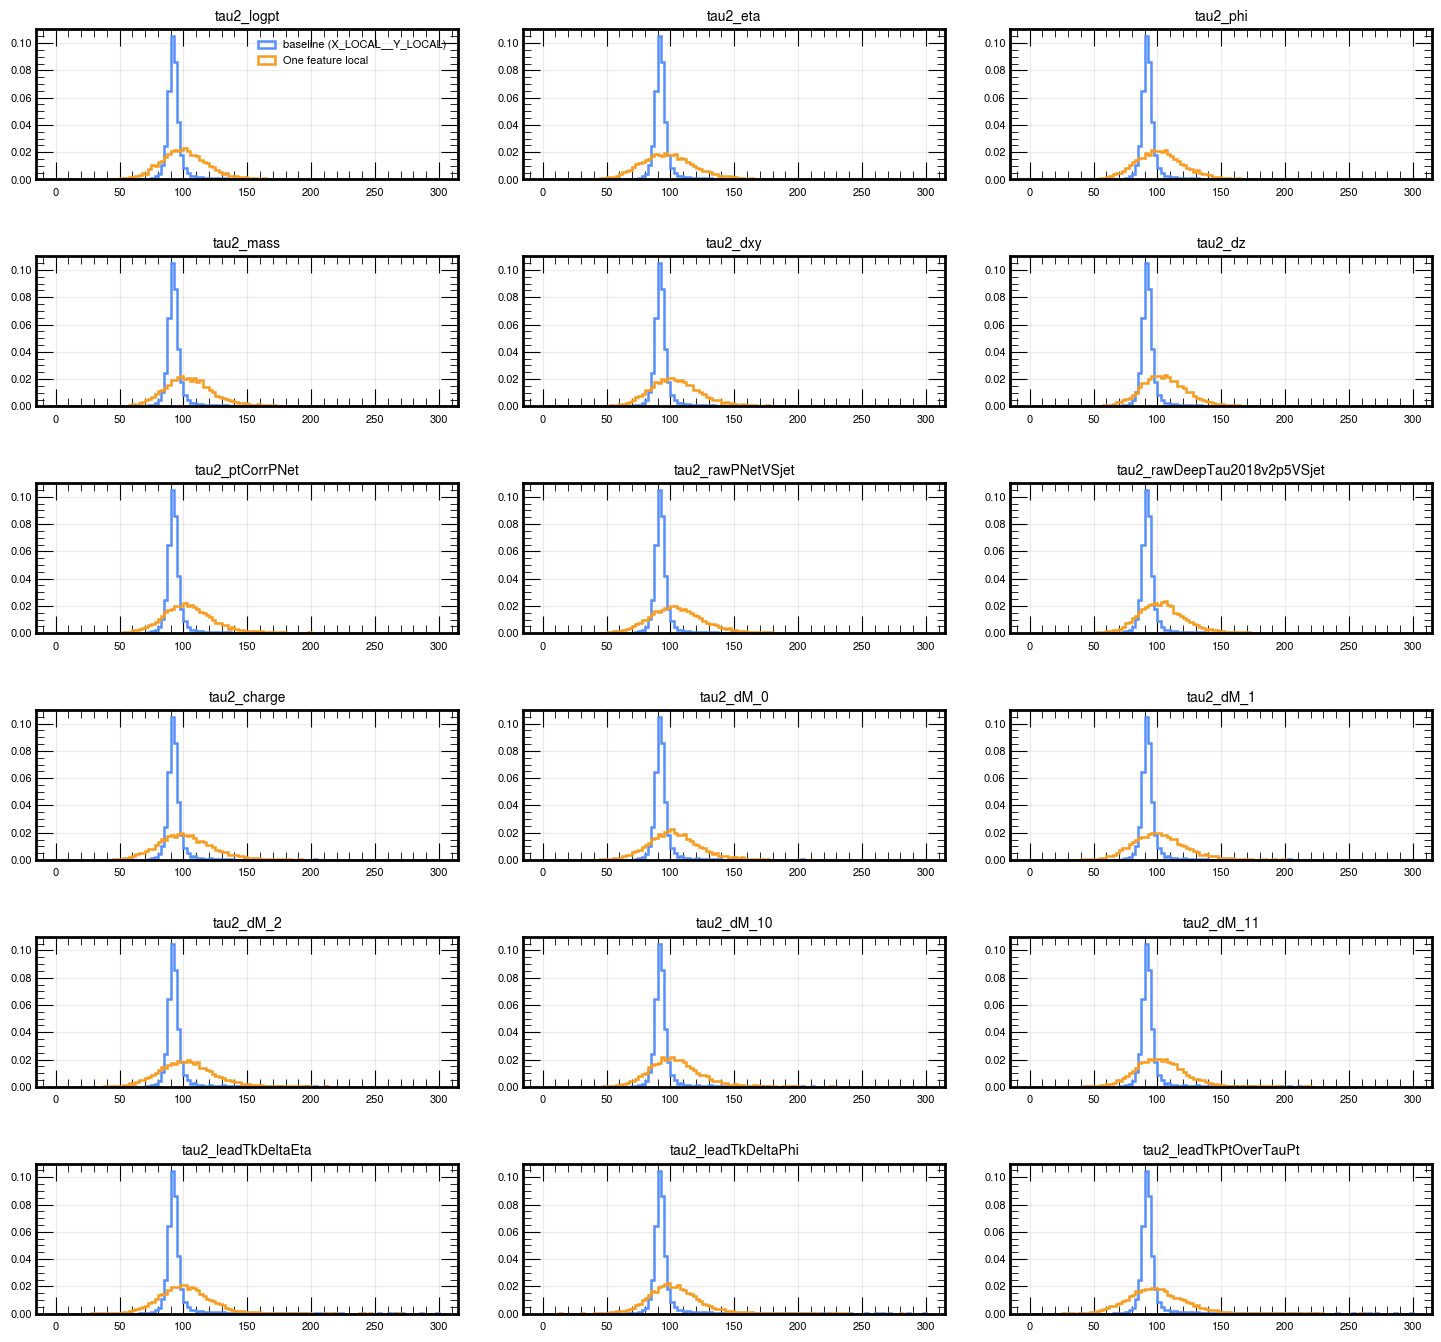

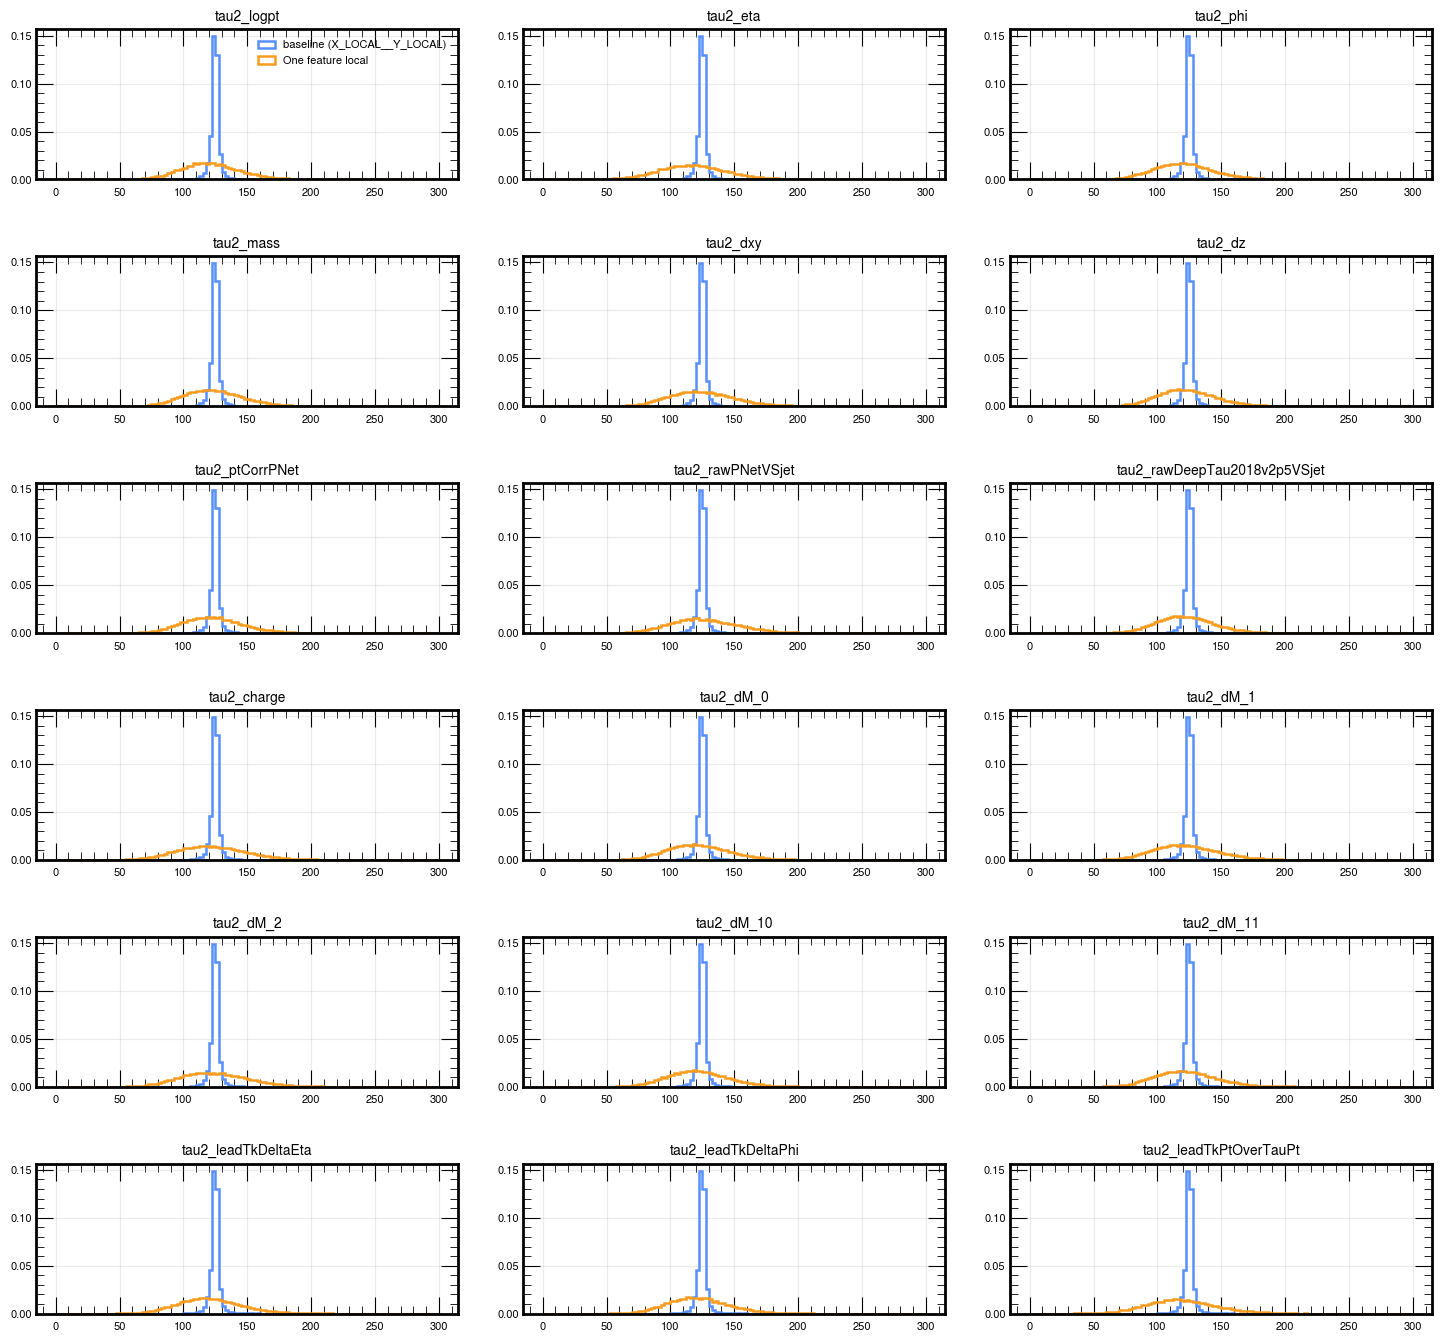

In [40]:
scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_dy,
    baseline_mass=m_baseline_dy,
    features=tau2_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=3,
    figsize=(15, 14),
)

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_h,
    baseline_mass=m_baseline_h,
    features=tau2_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=3,
    figsize=(15, 14),
)

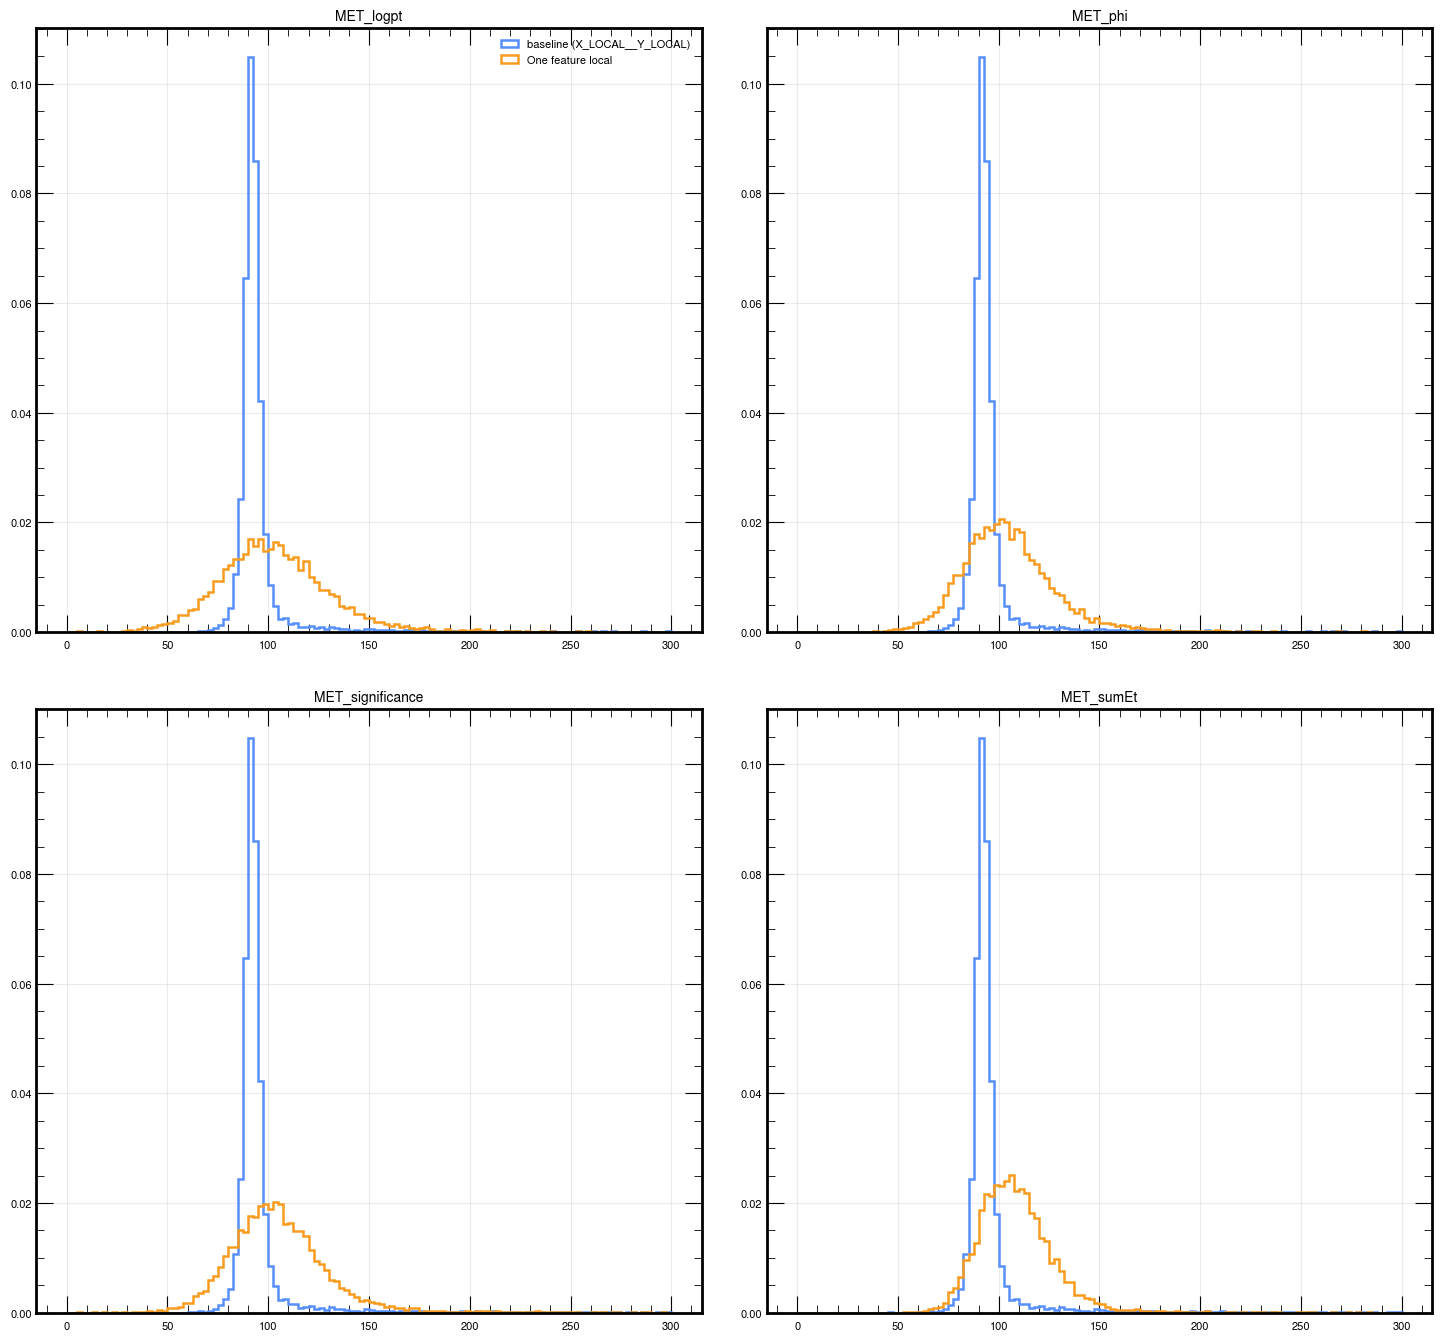

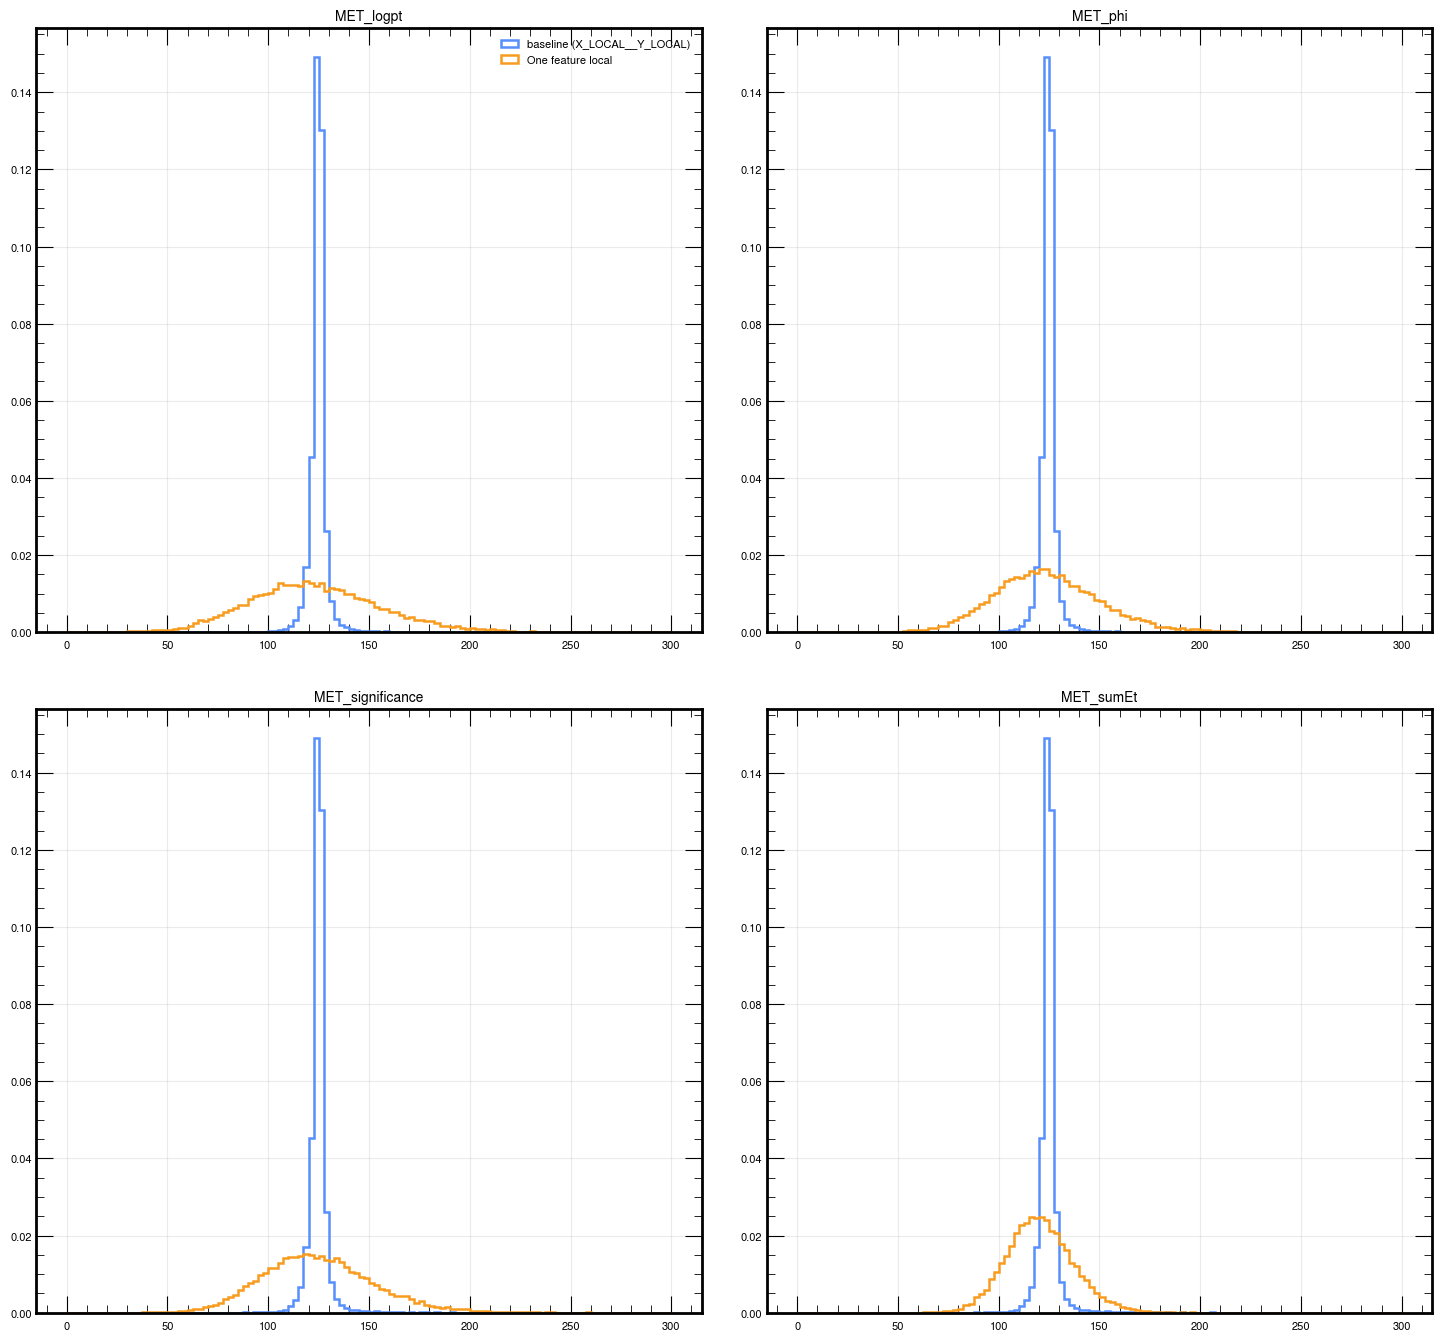

In [41]:
scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_dy,
    baseline_mass=m_baseline_dy,
    features=met_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=2,
    figsize=(15, 14),
)

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_h,
    baseline_mass=m_baseline_h,
    features=met_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=2,
    figsize=(15, 14),
)

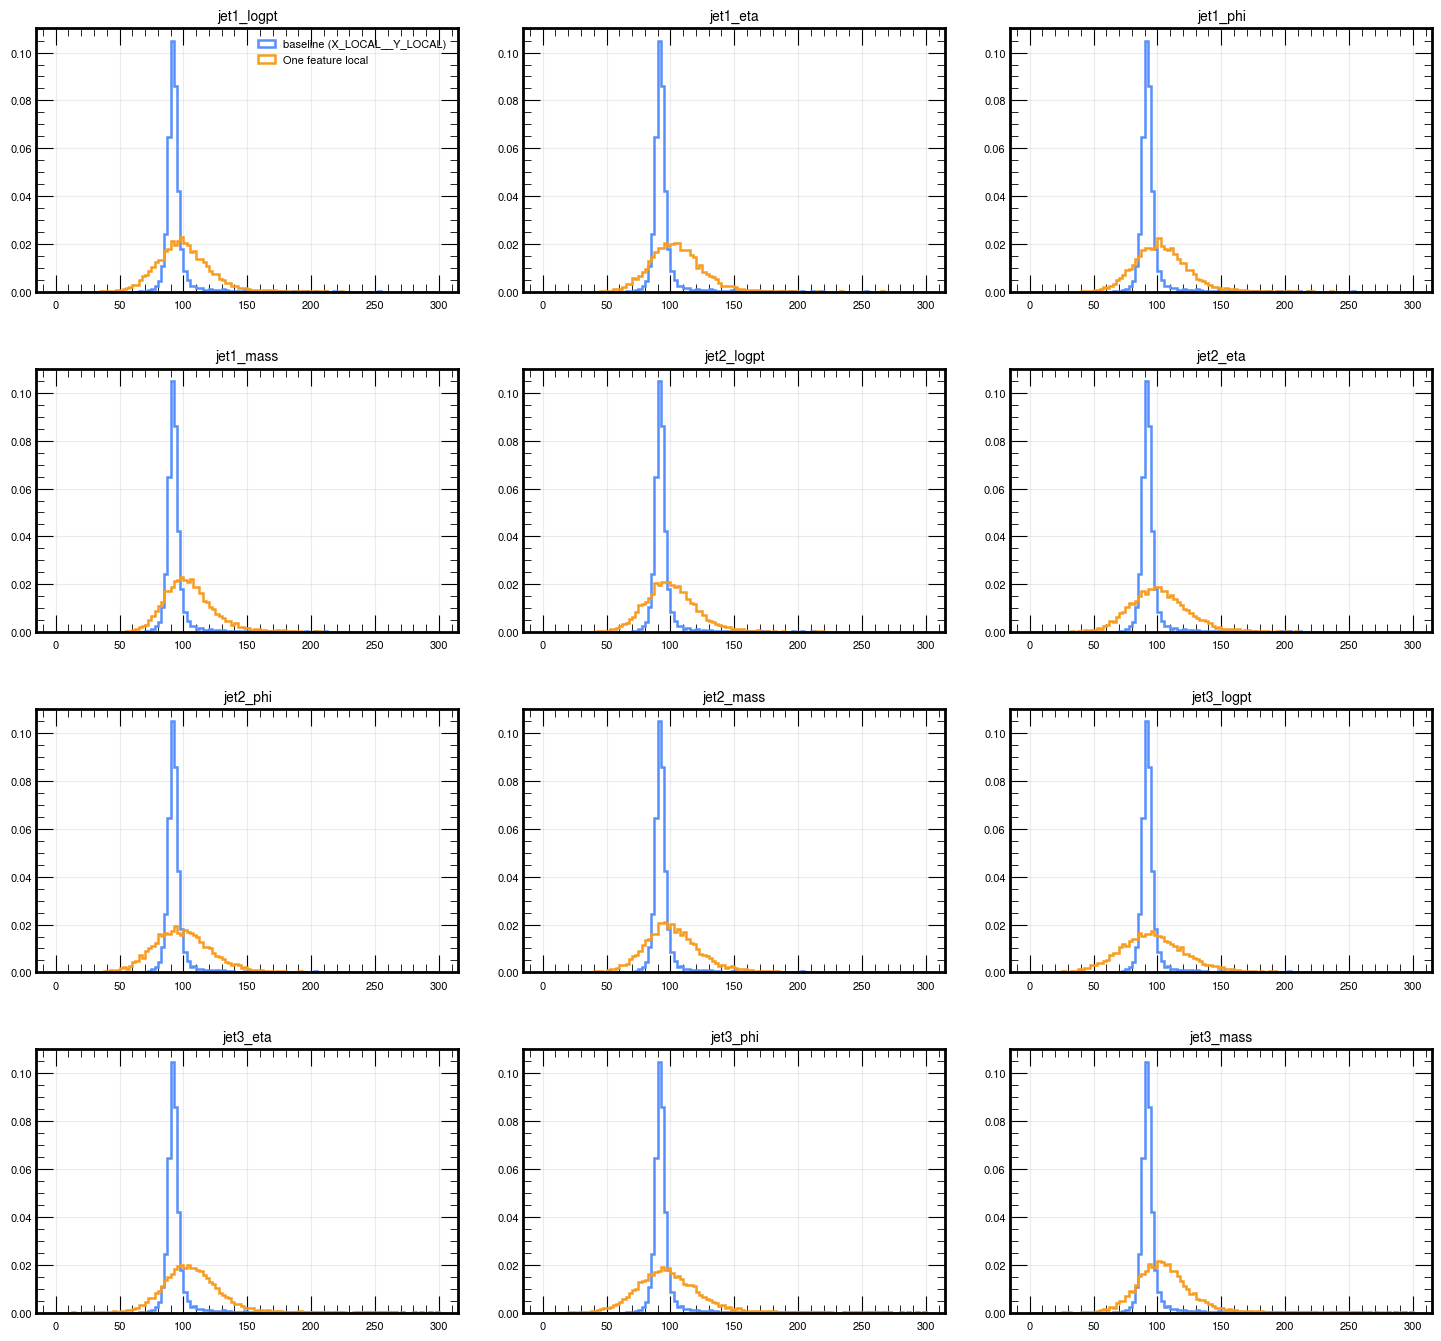

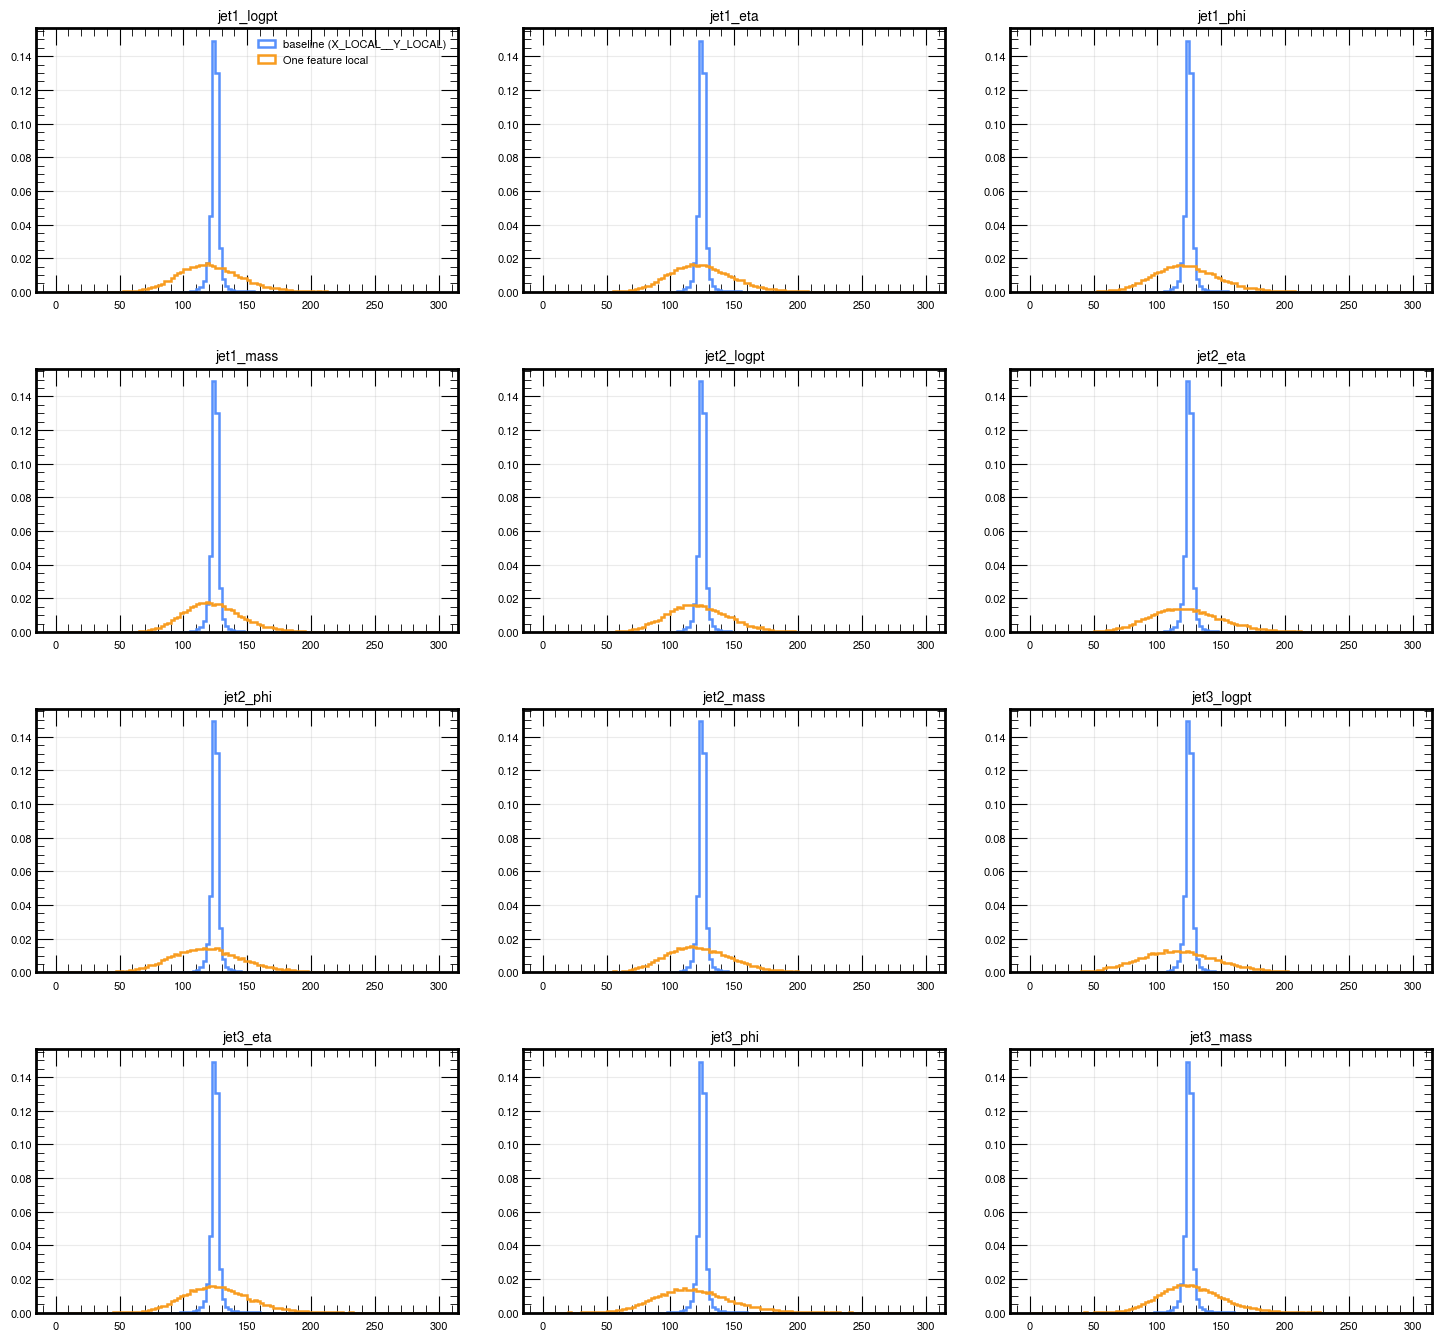

In [42]:
scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_dy,
    baseline_mass=m_baseline_dy,
    features=jet_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=3,
    figsize=(15, 14),
)

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_h,
    baseline_mass=m_baseline_h,
    features=jet_cols,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=3,
    figsize=(15, 14),
)

In [43]:
WINDOW = (110, 130)
VARIANT_KEY = "local"

rows = []

# --------------------------
# baseline
# --------------------------
res_base = analysis.compute_SB_from_split_masses(
    masses_h=m_baseline_h,
    masses_dy=m_baseline_dy,
    window=WINDOW,
)

rows.append({
    "feature": "BASELINE",
    "variant": BASELINE_MODE,
    "N_S": res_base["N_S"],
    "N_B": res_base["N_B"],
    "S_over_B": res_base["S_over_B"],
    "S_over_sqrtB": res_base["S_over_sqrtB"],
})

# --------------------------
# feature scan
# --------------------------
for feat in train_cols:
    if feat not in masses_feature_scan_h:
        print(f"[skip] {feat} not in masses_feature_scan_h")
        continue
    if feat not in masses_feature_scan_dy:
        print(f"[skip] {feat} not in masses_feature_scan_dy")
        continue

    if VARIANT_KEY not in masses_feature_scan_h[feat]:
        print(f"[skip] {feat}: key '{VARIANT_KEY}' not in masses_feature_scan_h[{feat}]")
        continue
    if VARIANT_KEY not in masses_feature_scan_dy[feat]:
        print(f"[skip] {feat}: key '{VARIANT_KEY}' not in masses_feature_scan_dy[{feat}]")
        continue

    masses_h_feat = masses_feature_scan_h[feat][VARIANT_KEY]
    masses_dy_feat = masses_feature_scan_dy[feat][VARIANT_KEY]

    res = analysis.compute_SB_from_split_masses(
        masses_h=masses_h_feat,
        masses_dy=masses_dy_feat,
        window=WINDOW,
    )

    rows.append({
        "feature": feat,
        "variant": VARIANT_KEY,
        "N_S": res["N_S"],
        "N_B": res["N_B"],
        "S_over_B": res["S_over_B"],
        "S_over_sqrtB": res["S_over_sqrtB"],
    })

df_sb = pd.DataFrame(rows)

In [44]:
sb_base = df_sb.loc[df_sb["feature"] == "BASELINE", "S_over_B"].iloc[0]

df_sb["delta_vs_baseline"] = df_sb["S_over_B"] - sb_base
df_sb["rel_delta_vs_baseline_%"] = 100.0 * df_sb["delta_vs_baseline"] / sb_base

df_sb = pd.concat([
    df_sb[df_sb["feature"] == "BASELINE"],
    df_sb[df_sb["feature"] != "BASELINE"]
], ignore_index=True)

df_sb

,feature,variant,N_S,N_B,S_over_B,S_over_sqrtB,delta_vs_baseline,rel_delta_vs_baseline_%
0,BASELINE,X_LOCAL__Y_LOCAL,24179,169,143.071006,1859.923077,0.000000,0.000000
1,tau1_logpt,local,8155,1672,4.877392,199.437044,-138.193614,-96.590929
2,tau1_eta,local,8540,2137,3.996256,184.737733,-139.074749,-97.206802
3,tau1_phi,local,7390,1983,3.726677,165.952226,-139.344329,-97.395226
4,tau1_mass,local,7631,1676,4.553103,186.399373,-138.517903,-96.817592
5,tau1_dxy,local,7779,2174,3.578197,166.837626,-139.492809,-97.499006
6,tau1_dz,local,7834,2044,3.832681,173.277878,-139.238325,-97.321134
7,tau1_ptCorrPNet,local,7739,2299,3.366246,161.404397,-139.704760,-97.647150
8,tau1_rawPNetVSjet,local,8013,2012,3.982604,178.641006,-139.088402,-97.216344
9,tau1_rawDeepTau2018v2p5VSjet,local,7272,1724,4.218097,175.139957,-138.852908,-97.051745


In [45]:
# ordino per impatto:
df_sb_sorted = pd.concat([
    df_sb[df_sb["feature"] == "BASELINE"],
    df_sb[df_sb["feature"] != "BASELINE"].sort_values("S_over_B", ascending=False)
], ignore_index=True)

df_sb_sorted


,feature,variant,N_S,N_B,S_over_B,S_over_sqrtB,delta_vs_baseline,rel_delta_vs_baseline_%
0,BASELINE,X_LOCAL__Y_LOCAL,24179,169,143.071006,1859.923077,0.000000,0.000000
1,jet1_logpt,local,7976,1633,4.884262,197.374959,-138.186744,-96.586127
2,tau1_logpt,local,8155,1672,4.877392,199.437044,-138.193614,-96.590929
3,tau2_logpt,local,8457,1788,4.729866,200.001187,-138.341140,-96.694043
4,MET_sumEt,local,11898,2569,4.631374,234.742601,-138.439632,-96.762884
5,tau1_dM_0,local,8069,1743,4.629375,193.272926,-138.441631,-96.764282
6,jet2_logpt,local,7984,1727,4.623046,192.120788,-138.447960,-96.768705
7,tau2_phi,local,8423,1836,4.587691,196.575986,-138.483315,-96.793417
8,tau2_eta,local,7276,1590,4.576101,182.471116,-138.494905,-96.801518
9,tau1_mass,local,7631,1676,4.553103,186.399373,-138.517903,-96.817592


In [46]:
# Voglio provare a confrontare anche con X_GLOBAL__Y_GLOBAL
WINDOW = (110, 130)
VARIANT_KEY = "local"

BASELINE_MODES = [
    "X_LOCAL__Y_LOCAL",
    "X_GLOBAL__Y_GLOBAL",
]

rows = []

# --------------------------------------------------
# Baselines
# --------------------------------------------------
for mode in BASELINE_MODES:
    m_baseline_dy = m_dy_npz[mode]
    m_baseline_h  = m_h_npz[mode]

    res_base = analysis.compute_SB_from_split_masses(
        masses_h=m_baseline_h,
        masses_dy=m_baseline_dy,
        window=WINDOW,
    )

    rows.append({
        "feature": "BASELINE",
        "variant": mode,
        "N_S": res_base["N_S"],
        "N_B": res_base["N_B"],
        "S_over_B": res_base["S_over_B"],
        "S_over_sqrtB": res_base["S_over_sqrtB"],
    })

# --------------------------------------------------
# Feature scan
# --------------------------------------------------
for feat in train_cols:
    if feat not in masses_feature_scan_h:
        print(f"[skip] {feat} not in masses_feature_scan_h")
        continue
    if feat not in masses_feature_scan_dy:
        print(f"[skip] {feat} not in masses_feature_scan_dy")
        continue

    if VARIANT_KEY not in masses_feature_scan_h[feat]:
        print(f"[skip] {feat}: key '{VARIANT_KEY}' not in masses_feature_scan_h[{feat}]")
        continue
    if VARIANT_KEY not in masses_feature_scan_dy[feat]:
        print(f"[skip] {feat}: key '{VARIANT_KEY}' not in masses_feature_scan_dy[{feat}]")
        continue

    masses_h_feat = masses_feature_scan_h[feat][VARIANT_KEY]
    masses_dy_feat = masses_feature_scan_dy[feat][VARIANT_KEY]

    res = analysis.compute_SB_from_split_masses(
        masses_h=masses_h_feat,
        masses_dy=masses_dy_feat,
        window=WINDOW,
    )

    rows.append({
        "feature": feat,
        "variant": VARIANT_KEY,
        "N_S": res["N_S"],
        "N_B": res["N_B"],
        "S_over_B": res["S_over_B"],
        "S_over_sqrtB": res["S_over_sqrtB"],
    })

df_sb = pd.DataFrame(rows)

df_sb = pd.concat([
    df_sb[df_sb["feature"] == "BASELINE"],
    df_sb[df_sb["feature"] != "BASELINE"]
], ignore_index=True)

df_baseline = df_sb[df_sb["feature"] == "BASELINE"]
df_features = df_sb[df_sb["feature"] != "BASELINE"].sort_values(
    "S_over_B",
    ascending=False
)

df_sb_sorted = pd.concat([df_baseline, df_features]).reset_index(drop=True)

df_sb_sorted

,feature,variant,N_S,N_B,S_over_B,S_over_sqrtB
0,BASELINE,X_LOCAL__Y_LOCAL,24179,169,143.071006,1859.923077
1,BASELINE,X_GLOBAL__Y_GLOBAL,18707,3546,5.275522,314.148348
2,jet1_logpt,local,7976,1633,4.884262,197.374959
3,tau1_logpt,local,8155,1672,4.877392,199.437044
4,tau2_logpt,local,8457,1788,4.729866,200.001187
5,MET_sumEt,local,11898,2569,4.631374,234.742601
6,tau1_dM_0,local,8069,1743,4.629375,193.272926
7,jet2_logpt,local,7984,1727,4.623046,192.120788
8,tau2_phi,local,8423,1836,4.587691,196.575986
9,tau2_eta,local,7276,1590,4.576101,182.471116


Top 5 features by S/B:
jet1_logpt
tau1_logpt
tau2_logpt
MET_sumEt
tau1_dM_0


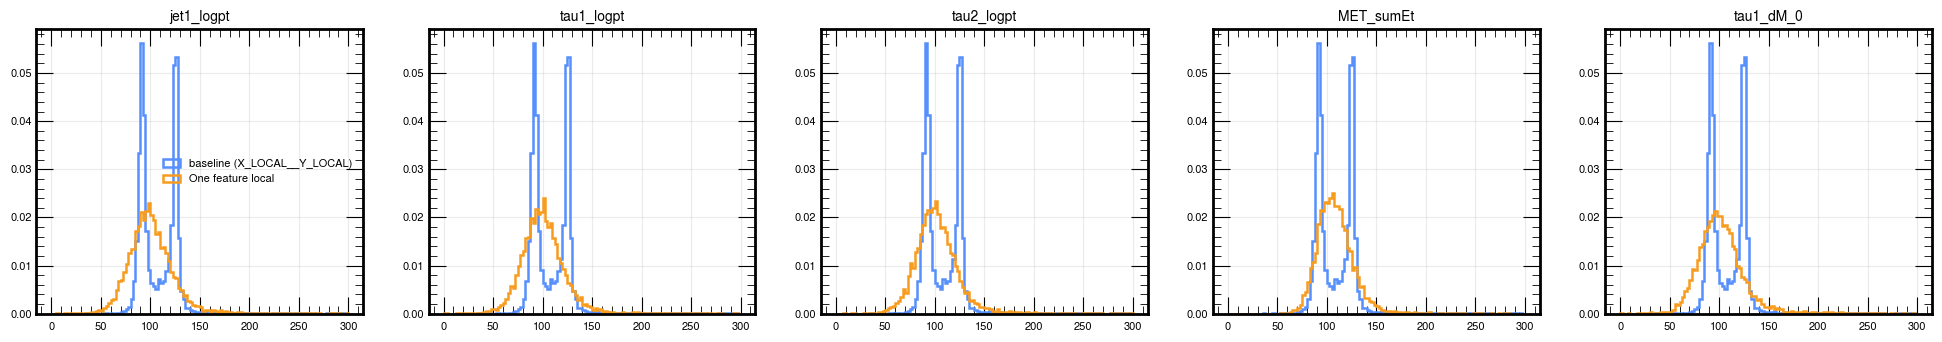

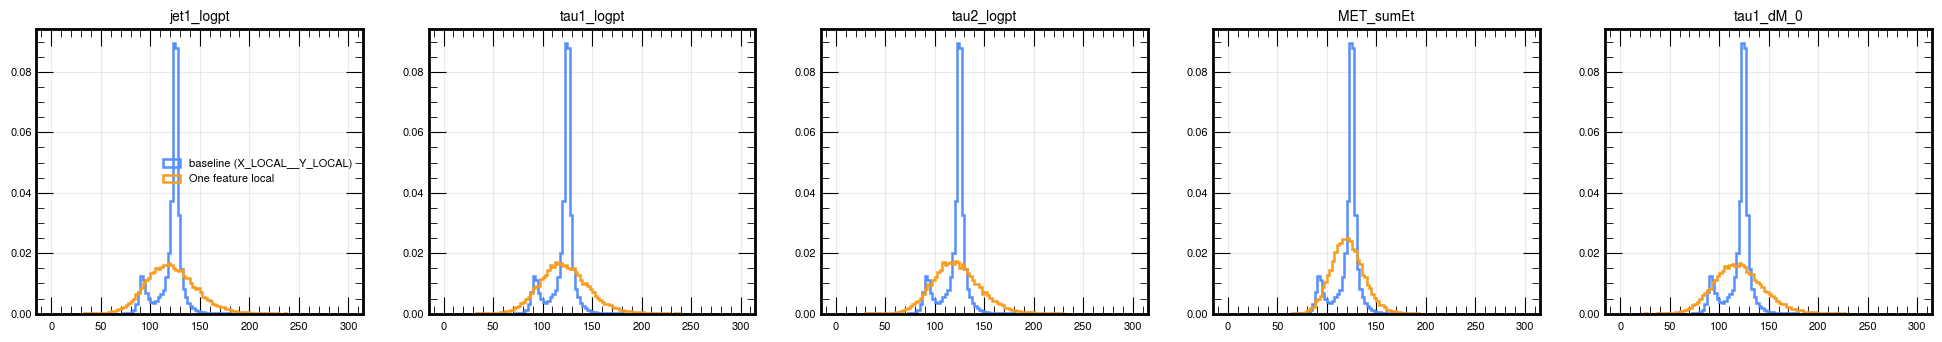

In [47]:
top5_features = (
    df_sb_sorted[df_sb_sorted["feature"] != "BASELINE"]
    .head(5)["feature"]
    .tolist()
)

top5_features

print("Top 5 features by S/B:")
for f in top5_features:
    print(f)

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_dy,
    baseline_mass=m_baseline_dy,
    features=top5_features,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=5,
    figsize=(20, 4),
)

scalingUtils.plot_mass_grid_vs_baseline(
    masses_feature_dict=masses_feature_scan_h,
    baseline_mass=m_baseline_h,
    features=top5_features,
    label_feature="One feature local",
    label_baseline=f"baseline ({BASELINE_MODE})",
    ncols=5,
    figsize=(20, 4),
)

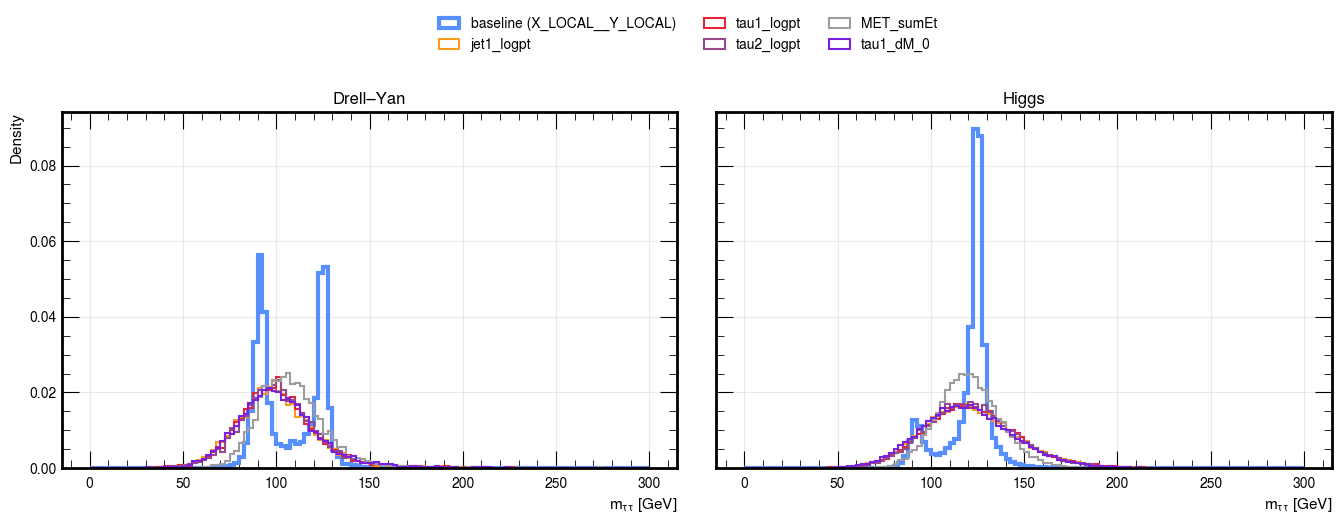

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# -----------------------
# DY
# -----------------------
axes[0].hist(
    m_baseline_dy,
    bins=120,
    range=(0,300),
    density=True,
    histtype="step",
    linewidth=3,
    label=f"baseline ({BASELINE_MODE})"
)

for feat in top5_features:
    masses = masses_feature_scan_dy[feat]["local"]

    axes[0].hist(
        masses,
        bins=120,
        range=(0,300),
        density=True,
        histtype="step",
        linewidth=1.5,
        label=feat
    )

axes[0].set_title("Drell–Yan")
axes[0].set_xlabel(r"$m_{\tau\tau}$ [GeV]")
axes[0].set_ylabel("Density")


# -----------------------
# Higgs
# -----------------------
axes[1].hist(
    m_baseline_h,
    bins=120,
    range=(0,300),
    density=True,
    histtype="step",
    linewidth=3,
    label=f"baseline ({BASELINE_MODE})"
)

for feat in top5_features:
    masses = masses_feature_scan_h[feat]["local"]

    axes[1].hist(
        masses,
        bins=120,
        range=(0,300),
        density=True,
        histtype="step",
        linewidth=1.5,
        label=feat
    )

axes[1].set_title("Higgs")
axes[1].set_xlabel(r"$m_{\tau\tau}$ [GeV]")


handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.7, 1.1), ncol=3)

plt.tight_layout()
plt.show()

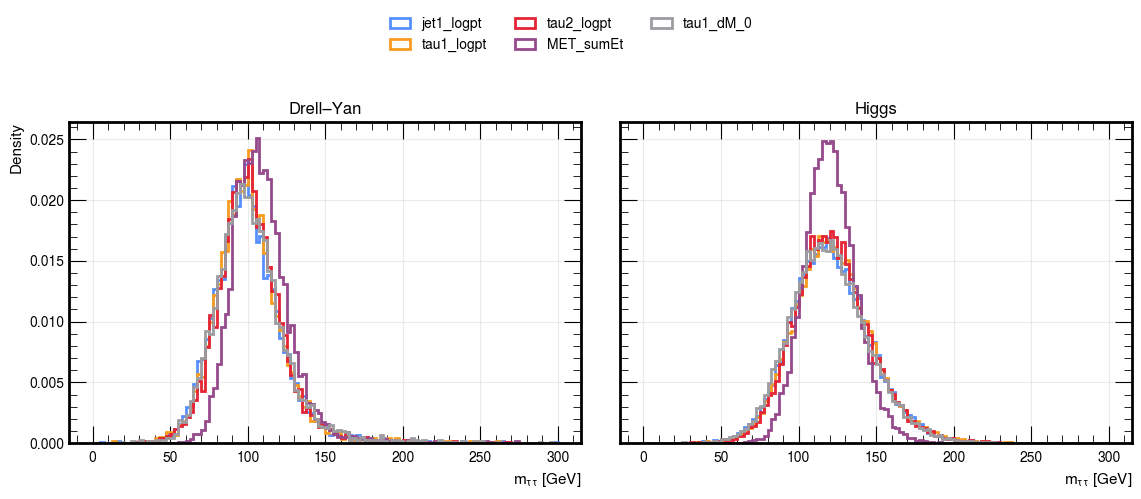

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# -----------------------
# DY
# -----------------------
for feat in top5_features:
    masses = masses_feature_scan_dy[feat]["local"]

    axes[0].hist(
        masses,
        bins=120,
        range=(0,300),
        density=True,
        histtype="step",
        linewidth=2,
        label=feat
    )

axes[0].set_title("Drell–Yan")
axes[0].set_xlabel(r"$m_{\tau\tau}$ [GeV]")
axes[0].set_ylabel("Density")


# -----------------------
# Higgs
# -----------------------
for feat in top5_features:
    masses = masses_feature_scan_h[feat]["local"]

    axes[1].hist(
        masses,
        bins=120,
        range=(0,300),
        density=True,
        histtype="step",
        linewidth=2,
        label=feat
    )

axes[1].set_title("Higgs")
axes[1].set_xlabel(r"$m_{\tau\tau}$ [GeV]")


# legenda globale
handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=3
)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [50]:
df_raw_new = df_all_test_raw[df_all_test_raw["jet2_logpt"] > 0]

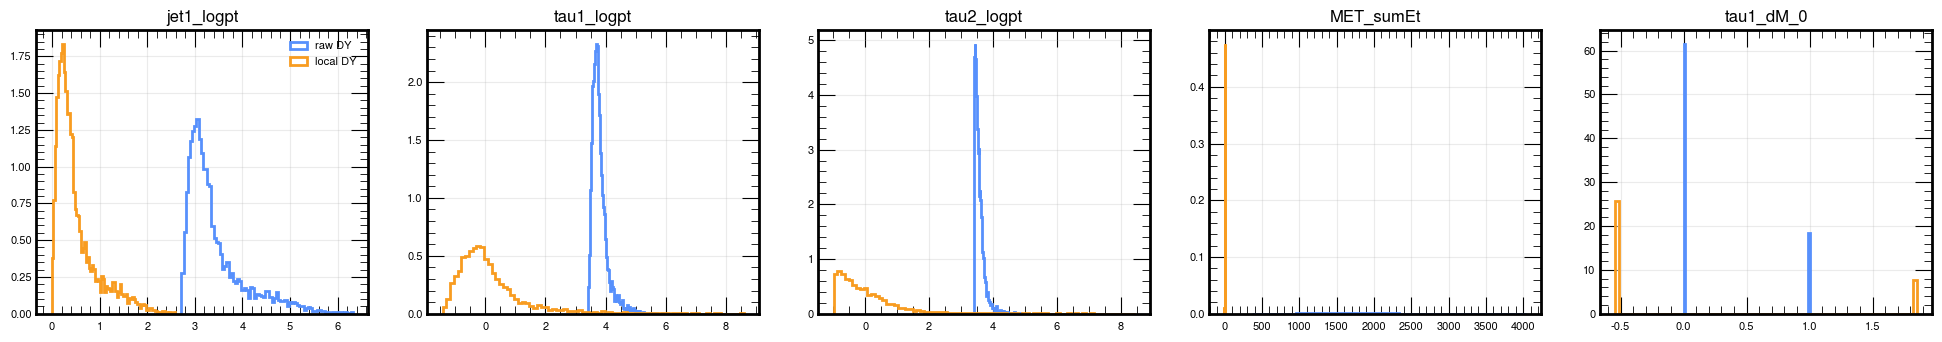

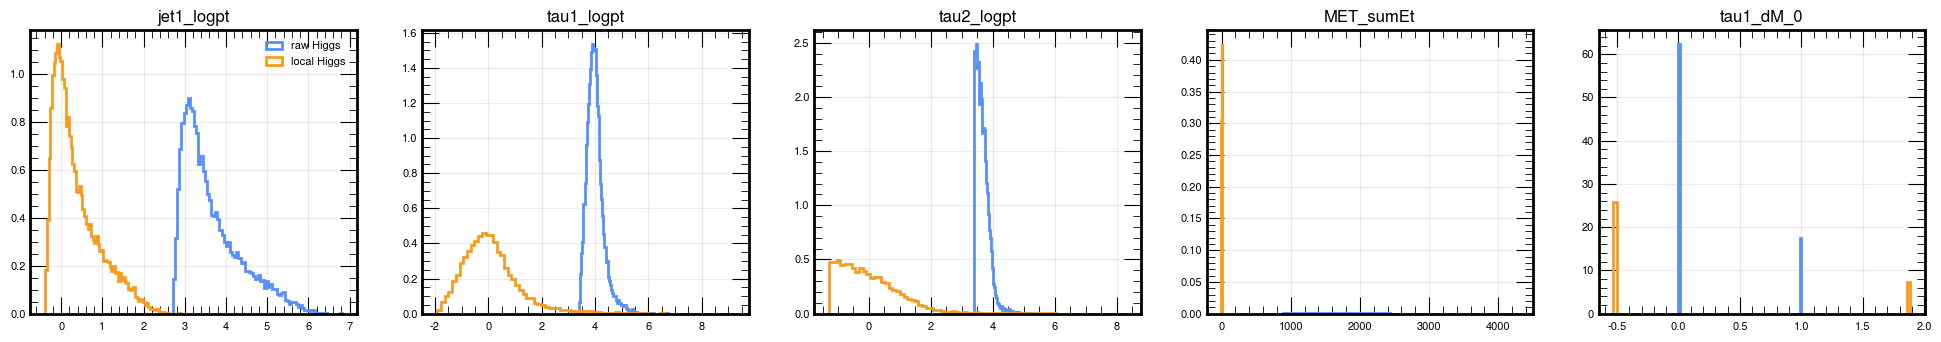

In [51]:
mask = (df_all_test_raw["class"] == 0) & (df_all_test_raw["jet2_logpt"] > 0)

scalingUtils.plot_feature_grid_raw_local(
    df_raw=df_all_test_raw[mask],
    df_local=df_all_test_local[mask],
    features=top5_features,
    class_value=0,
    ncols=5,
    figsize=(20,4),
)

mask = (df_all_test_raw["class"] == 1) & (df_all_test_raw["jet2_logpt"] > 0)

scalingUtils.plot_feature_grid_raw_local(
    df_raw=df_all_test_raw[mask],
    df_local=df_all_test_local[mask],
    features=top5_features,
    class_value=1,
    ncols=5,
    figsize=(20,4),
)

# Cumulative Trainings

In [52]:
import importlib
import fm.scaling_utils as ScalingUtils
importlib.reload(scalingUtils)

<module 'fm.scaling_utils' from '/Users/elisabreviglieri/Desktop/Tesi/Codici/Conditional_Flow_Matching/fm/scaling_utils.py'>

In [53]:
results_cumulative_scan = {}

for k in range(1, len(top5_features) + 1):
    selected = top5_features[:k]

    print("\n" + "="*80)
    print(f"TRAINING CUMULATIVE FEATURES ({k}): {selected}")
    print("="*80)

    res_local = scalingUtils.train_selected_features_variant(
        df_train=df_all_train,
        df_val=df_all_val,
        df_test=df_all_test,
        selected_features=selected,
        variant="local",
        train_cols=train_cols,
        y_cols=y_cols,
    )

    results_cumulative_scan[f"top{k}"] = {
        "features": selected,
        "local": res_local,
    }


TRAINING CUMULATIVE FEATURES (1): ['jet1_logpt']
[1feat | local | ep    1] train=3.574922  val=1.129448  best=1.129448  bad=0/30
[1feat | local | ep   10] train=1.010981  val=0.999018  best=0.999018  bad=0/30
[1feat | local | ep   20] train=0.869588  val=0.812146  best=0.812146  bad=0/30
[1feat | local | ep   30] train=0.711836  val=0.914037  best=0.657768  bad=1/30
[1feat | local | ep   40] train=0.655592  val=0.644118  best=0.632170  bad=2/30
[1feat | local | ep   50] train=0.619397  val=0.585829  best=0.585829  bad=0/30
[1feat | local | ep   60] train=0.678319  val=0.691996  best=0.585829  bad=10/30
[1feat | local | ep   70] train=0.594705  val=0.701457  best=0.563984  bad=1/30
[1feat | local | ep   80] train=0.745220  val=0.703619  best=0.557955  bad=6/30
[1feat | local | ep   90] train=0.578263  val=0.560855  best=0.554002  bad=1/30
[1feat | local | ep  100] train=0.557155  val=0.532704  best=0.532704  bad=0/30
[1feat | local | ep  110] train=0.528045  val=0.585355  best=0.518060

In [54]:
# Predictions:
preds_cumulative_scan = {}

for key, res_pair in results_cumulative_scan.items():

    print("\n" + "="*80)
    print(f"PREDICTIONS CUMULATIVE: {key} -> {res_pair['features']}")
    print("="*80)

    res_local = res_pair["local"]
    df_test_local = res_local["df_splits_scaled"][2]   # test già trasformato

    res_local_pred = dict(res_local)
    res_local_pred["scalers"] = dict(res_local["scalers"])
    res_local_pred["scalers"]["mode"] = "X_NONE__Y_NONE"

    df_pred_local = model.predict_tau_corr_auto(
        df=df_test_local,
        res=res_local_pred,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    preds_cumulative_scan[key] = {
        "features": res_pair["features"],
        "local": df_pred_local,
    }


PREDICTIONS CUMULATIVE: top1 -> ['jet1_logpt']

PREDICTIONS CUMULATIVE: top2 -> ['jet1_logpt', 'tau1_logpt']

PREDICTIONS CUMULATIVE: top3 -> ['jet1_logpt', 'tau1_logpt', 'tau2_logpt']

PREDICTIONS CUMULATIVE: top4 -> ['jet1_logpt', 'tau1_logpt', 'tau2_logpt', 'MET_sumEt']

PREDICTIONS CUMULATIVE: top5 -> ['jet1_logpt', 'tau1_logpt', 'tau2_logpt', 'MET_sumEt', 'tau1_dM_0']


In [55]:
# Masses:
masses_cumulative_scan = {}
masses_cumulative_scan_dy = {}
masses_cumulative_scan_h = {}

mask_dy = (df_all_test["class"] == 0).to_numpy()
mask_h  = (df_all_test["class"] == 1).to_numpy()

for key, pred_pair in preds_cumulative_scan.items():

    print("\n" + "="*80)
    print(f"MASSES CUMULATIVE: {key} -> {pred_pair['features']}")
    print("="*80)

    df_pred_local = pred_pair["local"]

    m_local = physics.inv_mass_two_taus_corrected_ratio(
        df_all_test["tau1_pt_reco_corrPNet"].to_numpy(),
        df_all_test["tau1_eta"].to_numpy(),
        df_all_test["tau1_phi"].to_numpy(),
        df_all_test["tau1_mass"].to_numpy(),
        df_pred_local["tau1_corr_pred"].to_numpy(),
        df_all_test["tau2_pt_reco_corrPNet"].to_numpy(),
        df_all_test["tau2_eta"].to_numpy(),
        df_all_test["tau2_phi"].to_numpy(),
        df_all_test["tau2_mass"].to_numpy(),
        df_pred_local["tau2_corr_pred"].to_numpy(),
    )

    masses_cumulative_scan[key] = {
        "features": pred_pair["features"],
        "local": m_local,
    }

    masses_cumulative_scan_dy[key] = {
        "features": pred_pair["features"],
        "local": m_local[mask_dy],
    }

    masses_cumulative_scan_h[key] = {
        "features": pred_pair["features"],
        "local": m_local[mask_h],
    }


MASSES CUMULATIVE: top1 -> ['jet1_logpt']

MASSES CUMULATIVE: top2 -> ['jet1_logpt', 'tau1_logpt']

MASSES CUMULATIVE: top3 -> ['jet1_logpt', 'tau1_logpt', 'tau2_logpt']

MASSES CUMULATIVE: top4 -> ['jet1_logpt', 'tau1_logpt', 'tau2_logpt', 'MET_sumEt']

MASSES CUMULATIVE: top5 -> ['jet1_logpt', 'tau1_logpt', 'tau2_logpt', 'MET_sumEt', 'tau1_dM_0']


In [56]:
rows = []

for key in masses_cumulative_scan.keys():

    res_sb = analysis.compute_SB_from_split_masses(
        masses_h=masses_cumulative_scan_h[key]["local"],
        masses_dy=masses_cumulative_scan_dy[key]["local"],
        window=(110, 140),
    )

    rows.append({
        "step": key,
        "features": ", ".join(masses_cumulative_scan[key]["features"]),
        "n_features": len(masses_cumulative_scan[key]["features"]),
        "N_S": res_sb["N_S"],
        "N_B": res_sb["N_B"],
        "S_over_B": res_sb["S_over_B"],
        "S_over_sqrtB": res_sb["S_over_sqrtB"],
    })

df_sb_cumulative = pd.DataFrame(rows).sort_values("n_features").reset_index(drop=True)
df_sb_cumulative

,step,features,n_features,N_S,N_B,S_over_B,S_over_sqrtB
0,top1,jet1_logpt,1,11713,2022,5.792779,260.481910
1,top2,"jet1_logpt, tau1_logpt",2,14180,1936,7.324380,322.272727
2,top3,"jet1_logpt, tau1_logpt, tau2_logpt",3,9795,2100,4.664286,213.744423
3,top4,"jet1_logpt, tau1_logpt, tau2_logpt, MET_sumEt",4,24486,423,57.886525,1190.550061
4,top5,"jet1_logpt, tau1_logpt, tau2_logpt, MET_sumEt,...",5,24359,524,46.486641,1064.127856


In [57]:
baseline_rows = []

for mode in ["X_LOCAL__Y_LOCAL", "X_GLOBAL__Y_GLOBAL"]:
    res_sb = analysis.compute_SB_from_split_masses(
        masses_h=m_h_npz[mode],
        masses_dy=m_dy_npz[mode],
        window=(110, 130),
    )

    baseline_rows.append({
        "step": f"BASELINE_{mode}",
        "features": mode,
        "n_features": np.nan,
        "N_S": res_sb["N_S"],
        "N_B": res_sb["N_B"],
        "S_over_B": res_sb["S_over_B"],
        "S_over_sqrtB": res_sb["S_over_sqrtB"],
    })

df_sb_cumulative_full = pd.concat(
    [pd.DataFrame(baseline_rows), df_sb_cumulative],
    ignore_index=True
)

df_sb_cumulative_full

,step,features,n_features,N_S,N_B,S_over_B,S_over_sqrtB
0,BASELINE_X_LOCAL__Y_LOCAL,X_LOCAL__Y_LOCAL,NaN,24179,169,143.071006,1859.923077
1,BASELINE_X_GLOBAL__Y_GLOBAL,X_GLOBAL__Y_GLOBAL,NaN,18707,3546,5.275522,314.148348
2,top1,jet1_logpt,1.0,11713,2022,5.792779,260.481910
3,top2,"jet1_logpt, tau1_logpt",2.0,14180,1936,7.324380,322.272727
4,top3,"jet1_logpt, tau1_logpt, tau2_logpt",3.0,9795,2100,4.664286,213.744423
5,top4,"jet1_logpt, tau1_logpt, tau2_logpt, MET_sumEt",4.0,24486,423,57.886525,1190.550061
6,top5,"jet1_logpt, tau1_logpt, tau2_logpt, MET_sumEt,...",5.0,24359,524,46.486641,1064.127856


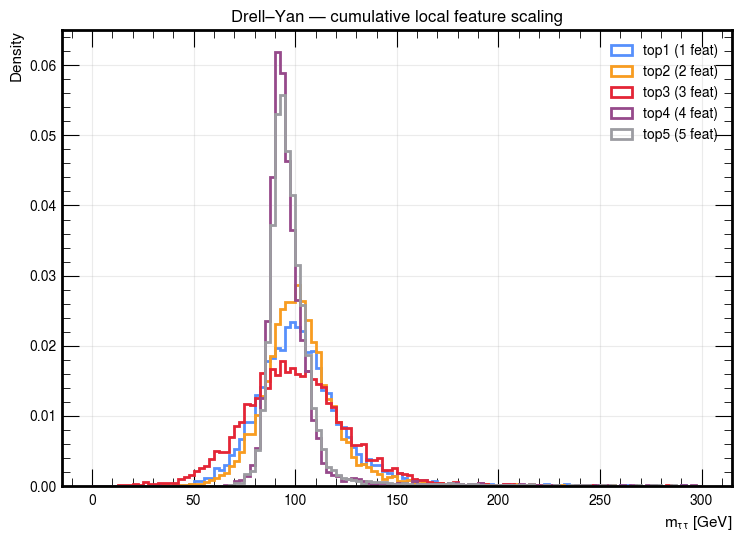

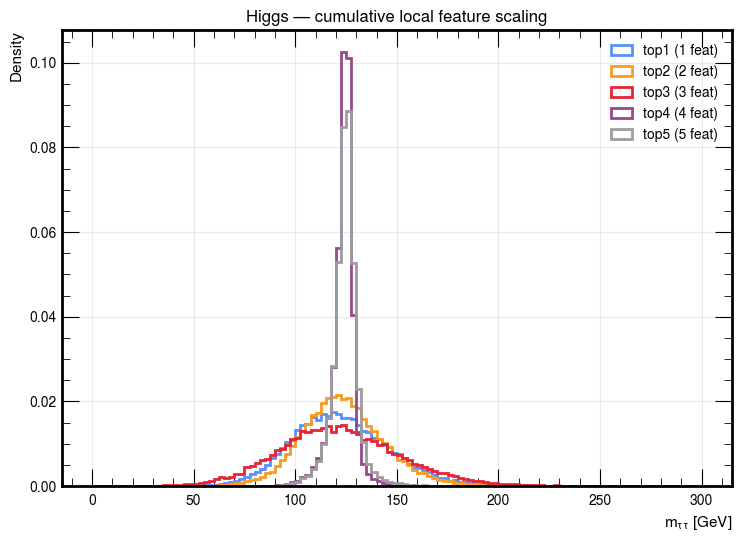

In [58]:
plt.figure(figsize=(8,6))

for key, mass_dict in masses_cumulative_scan_dy.items():
    feats = mass_dict["features"]
    label = f"{key} ({len(feats)} feat)"

    plt.hist(
        mass_dict["local"],
        bins=120,
        range=(0, 300),
        density=True,
        histtype="step",
        linewidth=2,
        label=label,
    )

plt.xlabel(r"$m_{\tau\tau}$ [GeV]")
plt.ylabel("Density")
plt.title("Drell–Yan — cumulative local feature scaling")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,6))

for key, mass_dict in masses_cumulative_scan_h.items():
    feats = mass_dict["features"]
    label = f"{key} ({len(feats)} feat)"

    plt.hist(
        mass_dict["local"],
        bins=120,
        range=(0, 300),
        density=True,
        histtype="step",
        linewidth=2,
        label=label,
    )

plt.xlabel(r"$m_{\tau\tau}$ [GeV]")
plt.ylabel("Density")
plt.title("Higgs — cumulative local feature scaling")
plt.legend()
plt.tight_layout()
plt.show()